In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [2]:
df = pd.read_csv('Exam_Score_Prediction_Modified.csv', index_col='student_id')
df.head()


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,performance_category,study_effectiveness
student_id,,,,,,,,,,,,,,
1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9,Pass,2.58262
2,23,male,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8,Pass,2.18376
3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3,Excellent,6.05184
4,20,male,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7,Fail,0.32428
5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7,Pass,0.63724


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1 to 20001
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   course                20000 non-null  object 
 3   study_hours           20000 non-null  float64
 4   class_attendance      20000 non-null  float64
 5   internet_access       20000 non-null  object 
 6   sleep_hours           20000 non-null  float64
 7   sleep_quality         20000 non-null  object 
 8   study_method          20000 non-null  object 
 9   facility_rating       20000 non-null  object 
 10  exam_difficulty       20000 non-null  object 
 11  exam_score            20000 non-null  float64
 12  performance_category  20000 non-null  object 
 13  study_effectiveness   20000 non-null  float64
dtypes: float64(5), int64(1), object(8)
memory usage: 2.3+ MB


In [ ]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nMissing Percentage:")
print((df.isnull().sum() / len(df)) * 100)


Missing Values:
age                     0
gender                  0
course                  0
study_hours             0
class_attendance        0
internet_access         0
sleep_hours             0
sleep_quality           0
study_method            0
facility_rating         0
exam_difficulty         0
exam_score              0
performance_category    0
study_effectiveness     0
dtype: int64

Missing Percentage:
age                     0.0
gender                  0.0
course                  0.0
study_hours             0.0
class_attendance        0.0
internet_access         0.0
sleep_hours             0.0
sleep_quality           0.0
study_method            0.0
facility_rating         0.0
exam_difficulty         0.0
exam_score              0.0
performance_category    0.0
study_effectiveness     0.0
dtype: float64


In [5]:
df. describe()


,age,study_hours,class_attendance,sleep_hours,exam_score,study_effectiveness
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000
mean,20.473300,4.007604,70.017365,7.00856,62.513225,2.805362
std,2.284458,2.308313,17.282262,1.73209,18.908491,1.805378
min,17.000000,0.080000,40.600000,4.10000,19.599000,0.032480
25%,18.000000,2.000000,55.100000,5.50000,48.800000,1.318942
50%,20.000000,4.040000,69.900000,7.00000,62.600000,2.621135
75%,22.000000,6.000000,85.000000,8.50000,76.300000,4.043760
max,24.000000,7.910000,99.400000,9.90000,100.000000,7.862540


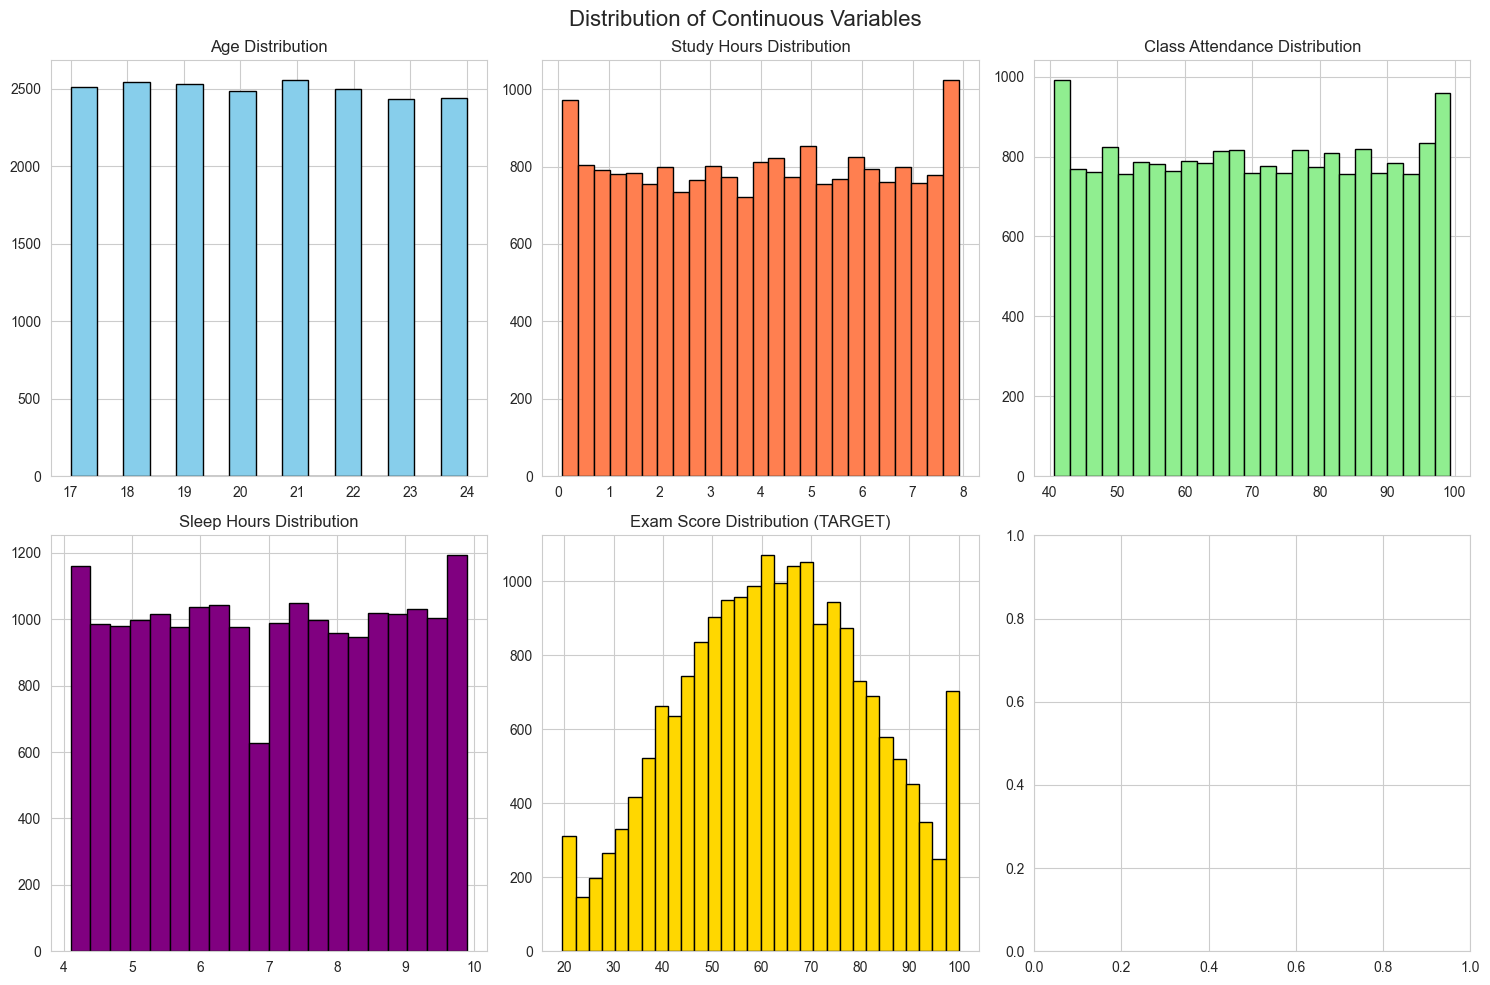

In [ ]:
# Set style
sns.set_style("whitegrid")

# Distribution of numerical continuous variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Continuous Variables', fontsize=16)

df['age'].hist(bins=15, ax=axes[0,0], edgecolor='black', color='skyblue')
axes[0,0].set_title('Age Distribution')

df['study_hours'].hist(bins=25, ax=axes[0,1], edgecolor='black', color='coral')
axes[0,1].set_title('Study Hours Distribution')

df['class_attendance'].hist(bins=25, ax=axes[0,2], edgecolor='black', color='lightgreen')
axes[0,2].set_title('Class Attendance Distribution')

df['sleep_hours'].hist(bins=20, ax=axes[1,0], edgecolor='black', color='purple')
axes[1,0].set_title('Sleep Hours Distribution')

df['exam_score'].hist(bins=30, ax=axes[1,1], edgecolor='black', color='gold')
axes[1,1].set_title('Exam Score Distribution (TARGET)')

plt.tight_layout()
plt.show()


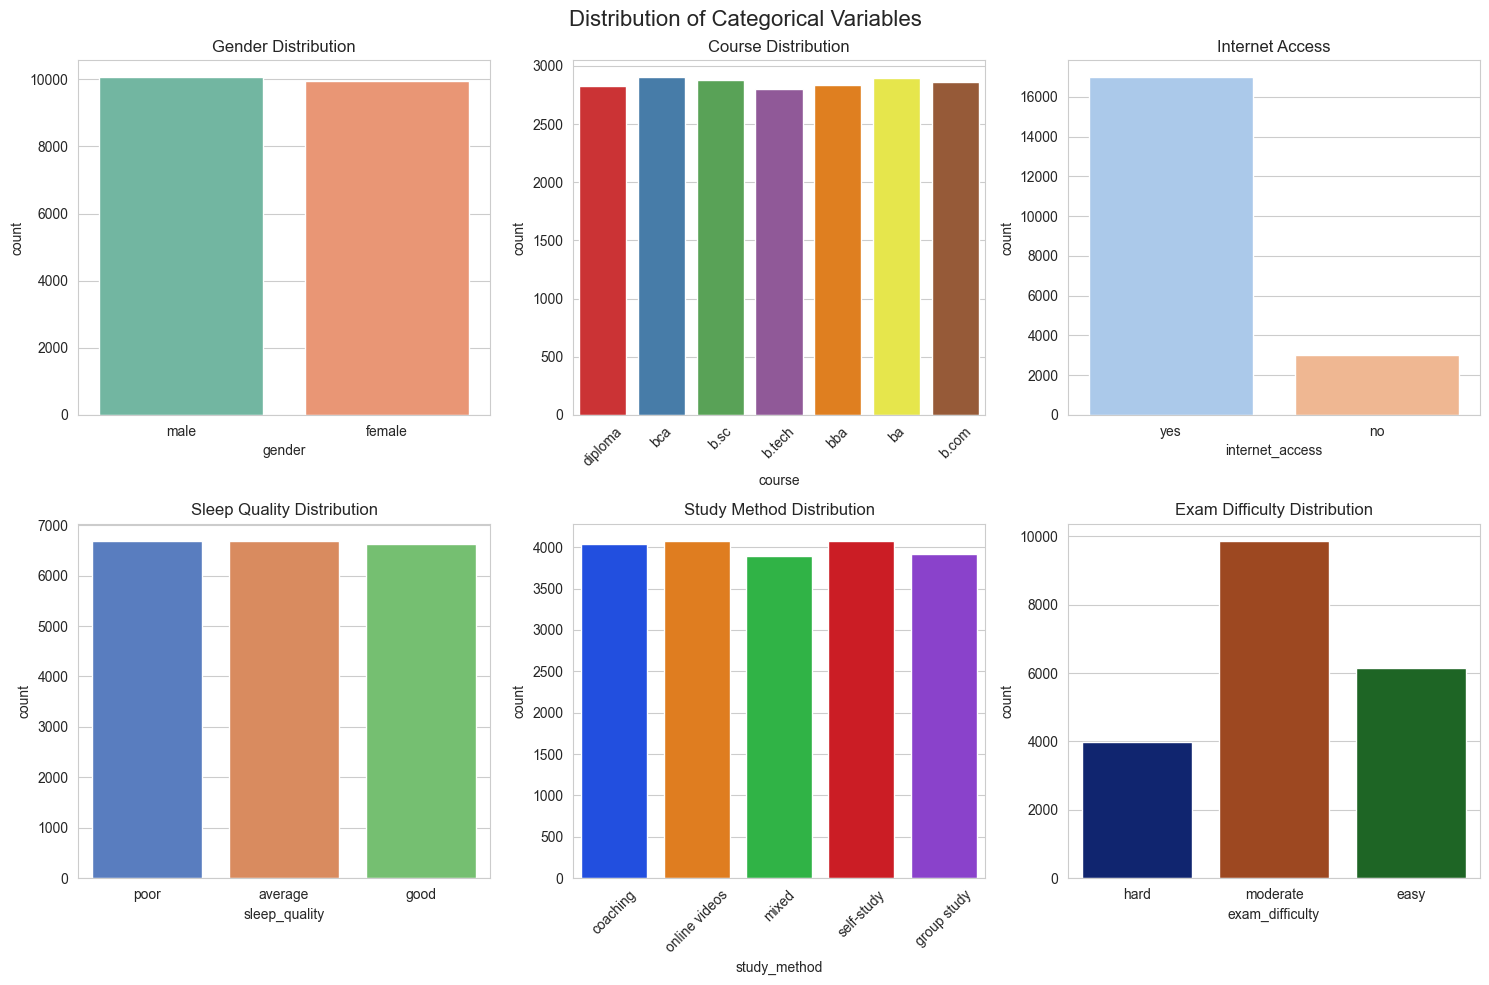

In [ ]:
# Distribution of categorical variables
fig, axes = plt. subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Variables', fontsize=16)

sns.countplot(data=df, x='gender', ax=axes[0,0], palette='Set2', hue='gender', dodge=False, legend=False)
axes[0,0].set_title('Gender Distribution')

sns.countplot(data=df, x='course', ax=axes[0,1], palette='Set1', hue='course', dodge=False, legend=False)
axes[0,1].set_title('Course Distribution')
axes[0,1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='internet_access', ax=axes[0,2], palette='pastel', hue='internet_access', dodge=False, legend=False)
axes[0,2].set_title('Internet Access')

sns.countplot(data=df, x='sleep_quality', ax=axes[1,0], palette='muted', hue='sleep_quality', dodge=False, legend=False)
axes[1,0].set_title('Sleep Quality Distribution')

sns.countplot(data=df, x='study_method', ax=axes[1,1], palette='bright', hue='study_method', dodge=False, legend=False)
axes[1,1].set_title('Study Method Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='exam_difficulty', ax=axes[1,2], palette='dark', hue='exam_difficulty', dodge=False, legend=False)
axes[1,2].set_title('Exam Difficulty Distribution')

plt.tight_layout()
plt.show()


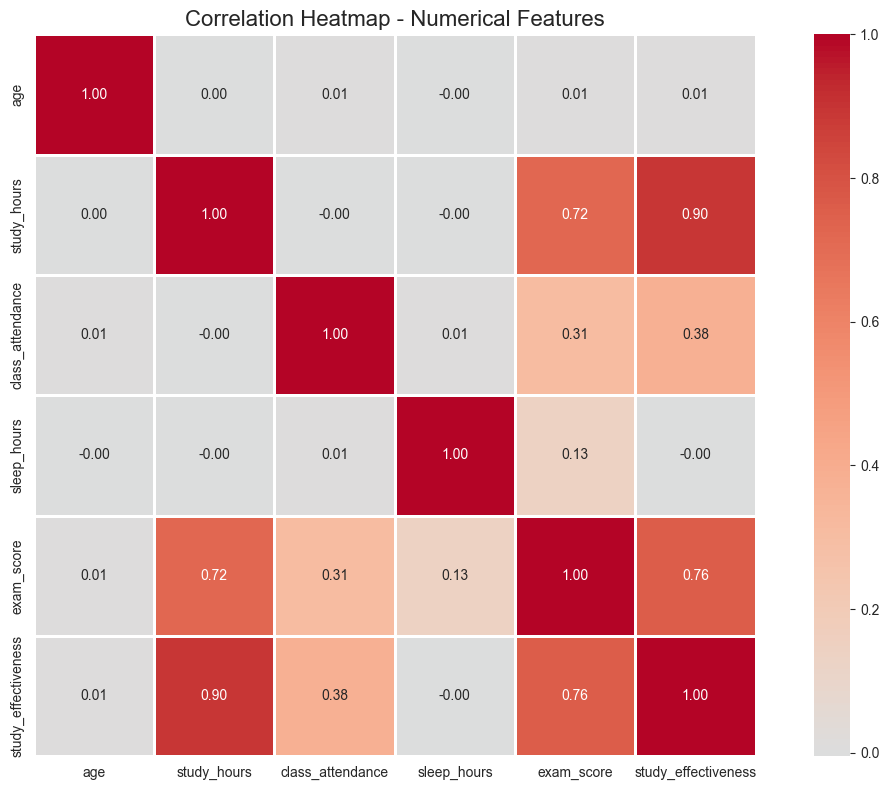


Correlations with Exam Score:
exam_score             1.000000
study_effectiveness    0.762154
study_hours            0.717788
class_attendance       0.308850
sleep_hours            0.133222
age                    0.006522
Name: exam_score, dtype: float64


In [ ]:
# Creating correlation matrix for numerical variables
plt.figure(figsize=(12, 8))

# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',  
            cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Heatmap - Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

# Show top correlations with exam_score
print("\nCorrelations with Exam Score:")
print(correlation_matrix['exam_score'].sort_values(ascending=False))


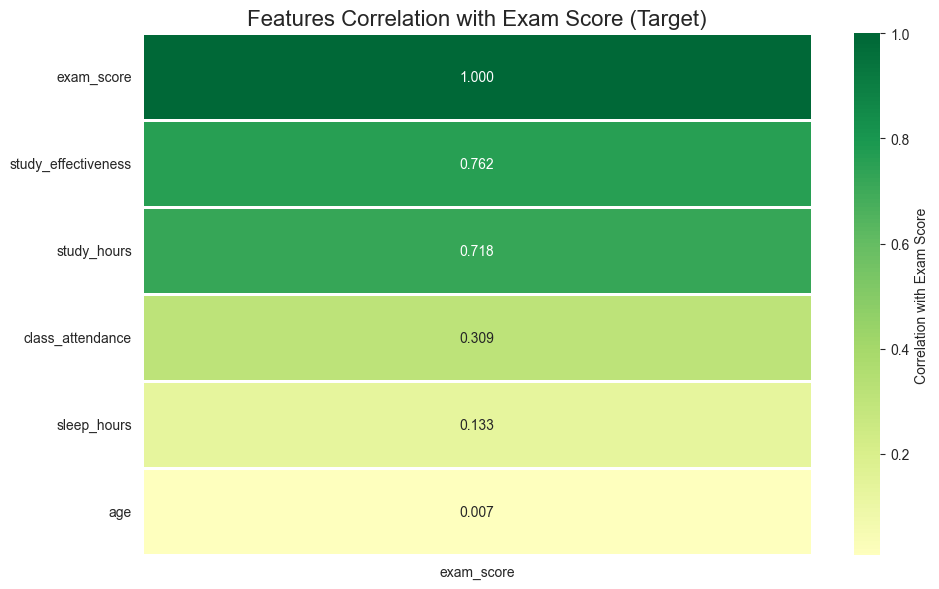

In [ ]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

# Get correlations with exam_score only (nice representation of output above)
exam_corr = correlation_matrix[['exam_score']].sort_values(by='exam_score', ascending=False)

sns.heatmap(exam_corr, annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, 
            linewidths=2, cbar_kws={'label': 'Correlation with Exam Score'})
plt.title('Features Correlation with Exam Score (Target)', fontsize=16)
plt.tight_layout()
plt.show()


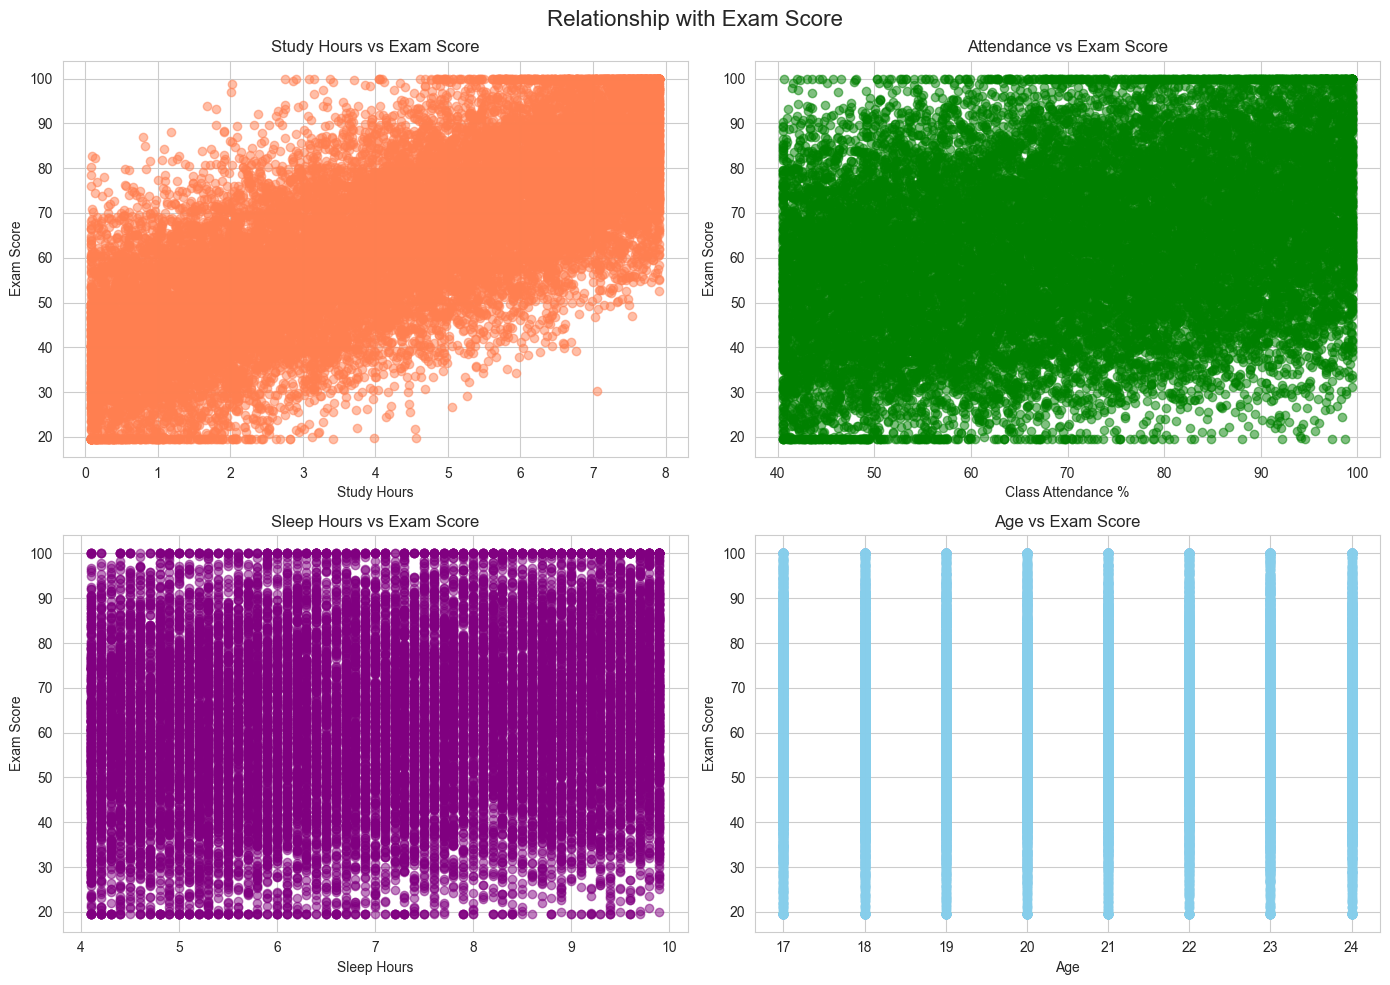

In [ ]:
# Scatter plots with exam_score and our features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Relationship with Exam Score', fontsize=16)

axes[0,0].scatter(df['study_hours'], df['exam_score'], alpha=0.5, color='coral')
axes[0,0].set_xlabel('Study Hours')
axes[0,0].set_ylabel('Exam Score')
axes[0,0].set_title('Study Hours vs Exam Score')

axes[0,1].scatter(df['class_attendance'], df['exam_score'], alpha=0.5, color='green')
axes[0,1].set_xlabel('Class Attendance %')
axes[0,1].set_ylabel('Exam Score')
axes[0,1].set_title('Attendance vs Exam Score')

axes[1,0].scatter(df['sleep_hours'], df['exam_score'], alpha=0.5, color='purple')
axes[1,0].set_xlabel('Sleep Hours')
axes[1,0].set_ylabel('Exam Score')
axes[1,0].set_title('Sleep Hours vs Exam Score')

axes[1,1].scatter(df['age'], df['exam_score'], alpha=0.5, color='skyblue')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Exam Score')
axes[1,1].set_title('Age vs Exam Score')

plt.tight_layout()
plt.show()


In [11]:
# Group statistics
print("\n=== Exam Score Statistics by Study Method ===")
print(df. groupby('study_method')['exam_score'].describe())

print("\n=== Exam Score Statistics by Course ===")
print(df.groupby('course')['exam_score'].describe())

print("\n=== Exam Score Statistics by Sleep Quality ===")
print(df.groupby('sleep_quality')['exam_score'].describe())



=== Exam Score Statistics by Study Method ===
                count       mean        std     min   25%    50%   75%    max
study_method                                                                 
coaching       4036.0  68.550963  18.415747  19.599  55.7  68.80  82.7  100.0
group study    3922.0  60.967482  18.525262  19.599  47.4  61.15  74.4  100.0
mixed          3894.0  64.242879  18.419535  19.599  51.0  64.60  77.6  100.0
online videos  4069.0  60.151694  18.748836  19.599  46.7  59.90  73.9  100.0
self-study     4079.0  58.729919  18.766427  19.599  44.8  58.70  72.0  100.0

=== Exam Score Statistics by Course ===
          count       mean        std     min     25%    50%     75%    max
course                                                                     
b.com    2864.0  62.333197  18.612410  19.599  49.100  62.15  75.800  100.0
b.sc     2878.0  62.718993  19.005497  19.599  49.300  63.10  76.300  100.0
b.tech   2798.0  62.653529  19.002387  19.599  48.800  62.60  

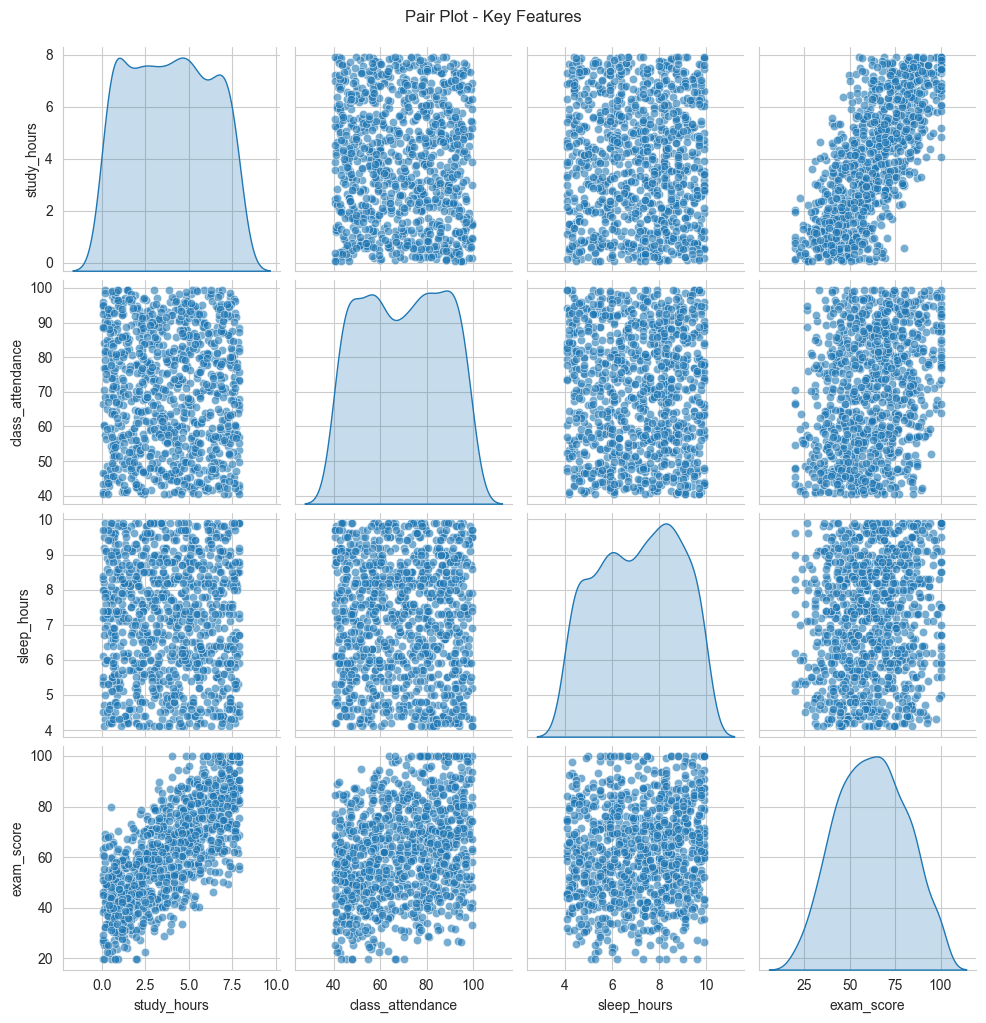

In [ ]:
# Sample for pair plot (20K points is too much so we use 1K)
sample_df = df.sample(n=1000, random_state=42)
sns.pairplot(sample_df[['study_hours', 'class_attendance', 
                         'sleep_hours', 'exam_score']], 
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot - Key Features', y=1.02)
plt.show()


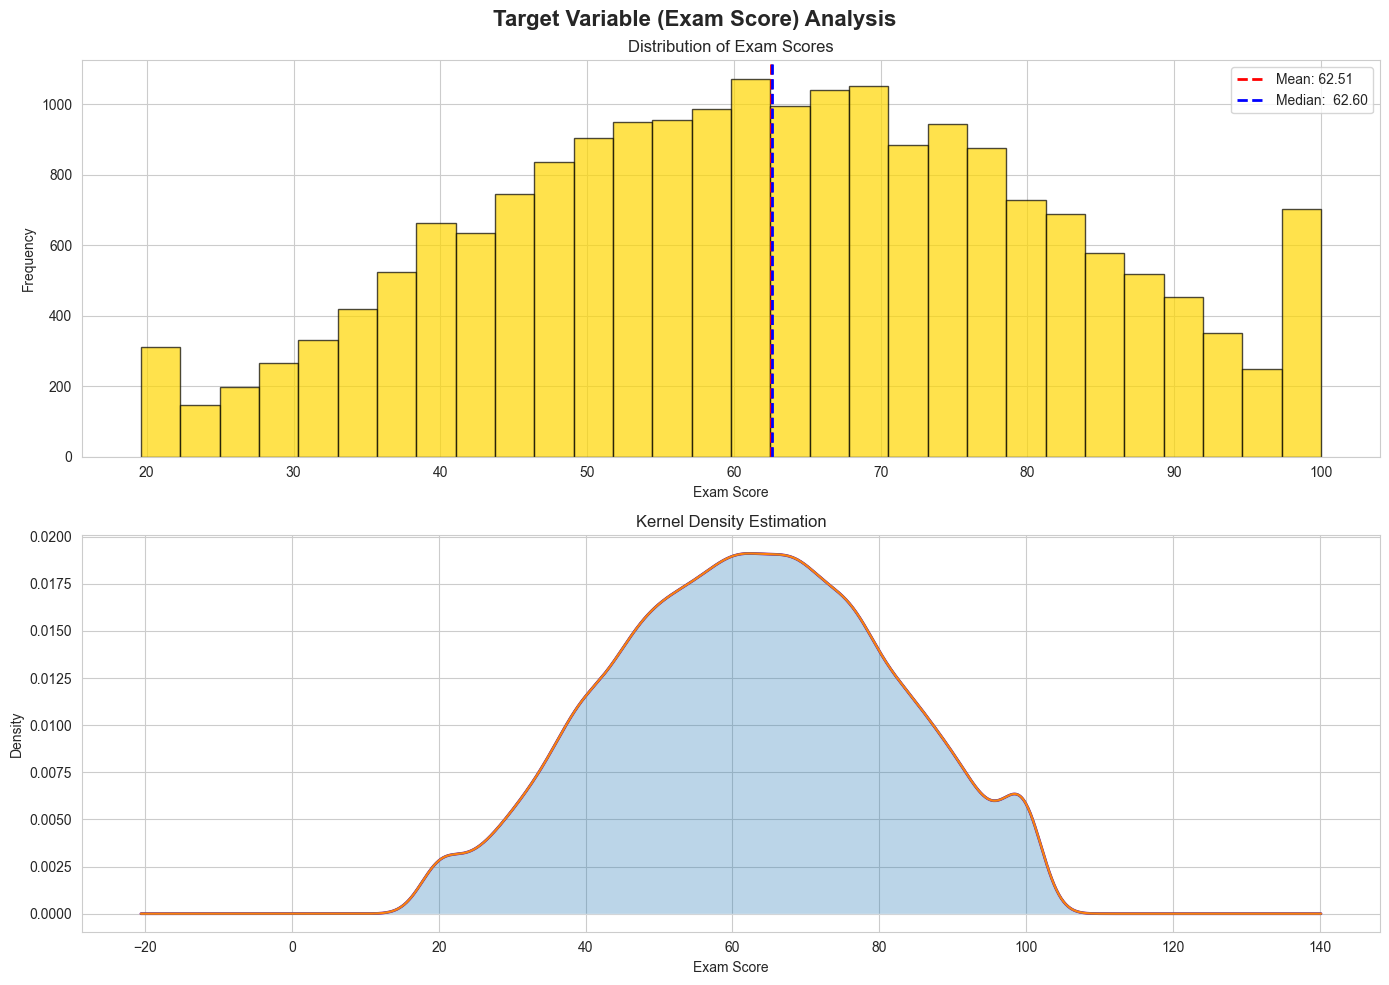

TARGET VARIABLE STATISTICS (Exam Score)
Mean: 62.51
Median:  62.60
Mode: 100.00
Std Dev: 18.91
Variance: 357.53
Min: 19.60
Max: 100.00
Range: 80.40
Skewness: -0.05
Kurtosis: -0.62

Percentiles:
0.25     48.8
0.50     62.6
0.75     76.3
0.90     88.0
0.95     94.2
0.99    100.0
Name: exam_score, dtype: float64


In [ ]:
# ========== TARGET VARIABLE ANALYSIS ==========
fig, axes = plt.subplots(2, figsize=(14, 10))
fig.suptitle('Target Variable (Exam Score) Analysis', fontsize=16, fontweight='bold')

# 1. Histogram with KDE (Kernel Density Estimation)
axes[0].hist(df['exam_score'], bins=30, edgecolor='black', alpha=0.7, color='gold')
axes[0].axvline(df['exam_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["exam_score"].mean():.2f}')
axes[0].axvline(df['exam_score'].median(), color='blue', linestyle='--', linewidth=2, label=f'Median:  {df["exam_score"].median():.2f}')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Exam Scores')
axes[0].legend()

# 2. KDE plot
df['exam_score'].plot(kind='kde', ax=axes[1], color='purple', linewidth=2)
axes[1].set_xlabel('Exam Score')
axes[1].set_title('Kernel Density Estimation')
axes[1].fill_between(df['exam_score'].plot(kind='kde').get_lines()[0].get_data()[0], 
                        df['exam_score'].plot(kind='kde').get_lines()[0].get_data()[1], 
                        alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("="*50)
print("TARGET VARIABLE STATISTICS (Exam Score)")
print("="*50)
print(f"Mean: {df['exam_score'].mean():.2f}")
print(f"Median:  {df['exam_score'].median():.2f}")
print(f"Mode: {df['exam_score']. mode()[0]:.2f}")
print(f"Std Dev: {df['exam_score'].std():.2f}")
print(f"Variance: {df['exam_score'].var():.2f}")
print(f"Min: {df['exam_score'].min():.2f}")
print(f"Max: {df['exam_score'].max():.2f}")
print(f"Range: {df['exam_score']. max() - df['exam_score'].min():.2f}")
print(f"Skewness: {df['exam_score']. skew():.2f}")
print(f"Kurtosis: {df['exam_score']. kurtosis():.2f}")
print(f"\nPercentiles:")
print(df['exam_score'].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))


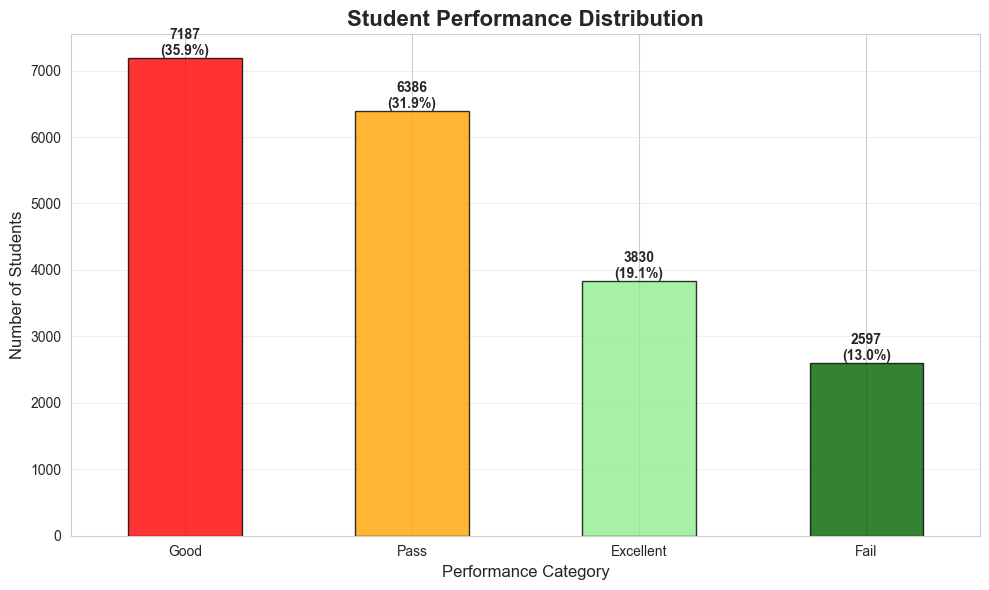

In [14]:
# Create performance categories
df['performance_category'] = pd. cut(df['exam_score'], 
                                     bins=[0, 40, 60, 80, 100],
                                     labels=['Fail', 'Pass', 'Good', 'Excellent'])

# Count plot
plt.figure(figsize=(10, 6))
performance_counts = df['performance_category'].value_counts()
colors = ['red', 'orange', 'lightgreen', 'darkgreen']
performance_counts.plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)
plt.title('Student Performance Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Performance Category', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add percentages on bars
for i, v in enumerate(performance_counts):
    plt.text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


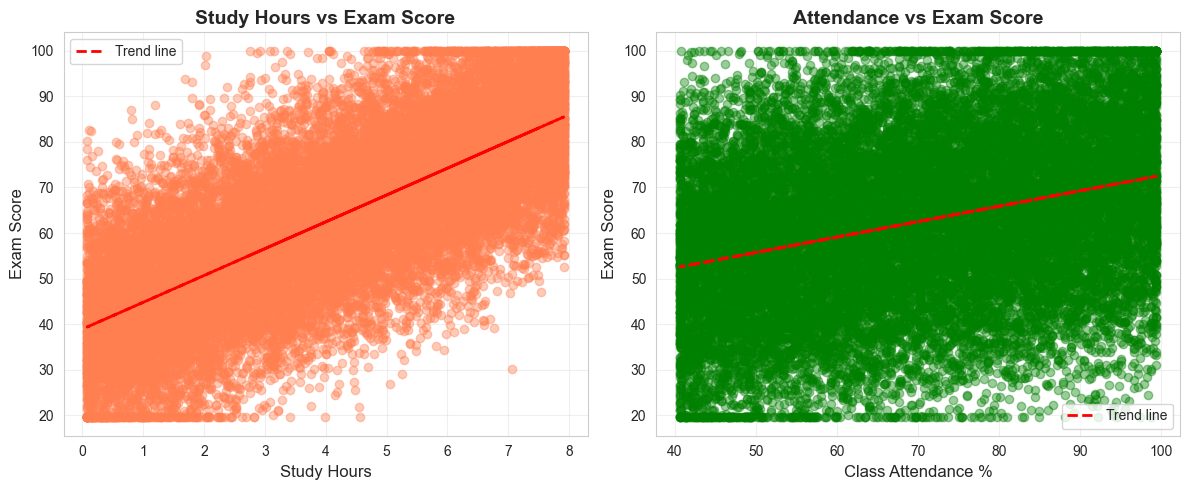

In [15]:
# Study hours impact on exam score (with regression line)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['study_hours'], df['exam_score'], alpha=0.4, color='coral')
z = np.polyfit(df['study_hours'], df['exam_score'], 1)
p = np.poly1d(z)
plt.plot(df['study_hours'], p(df['study_hours']), "r--", linewidth=2, label=f'Trend line')
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.title('Study Hours vs Exam Score', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Attendance impact
plt.subplot(1, 2, 2)
plt.scatter(df['class_attendance'], df['exam_score'], alpha=0.4, color='green')
z = np.polyfit(df['class_attendance'], df['exam_score'], 1)
p = np.poly1d(z)
plt.plot(df['class_attendance'], p(df['class_attendance']), "r--", linewidth=2, label=f'Trend line')
plt.xlabel('Class Attendance %', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.title('Attendance vs Exam Score', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


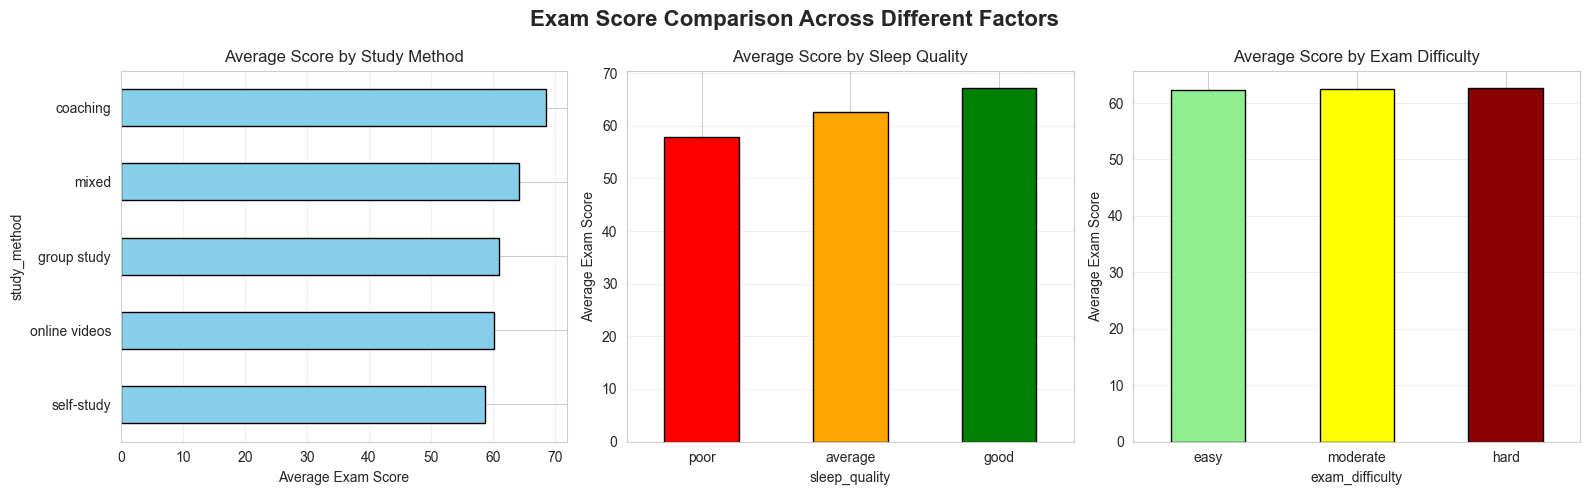

In [16]:
# Compare multiple study methods side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exam Score Comparison Across Different Factors', fontsize=16, fontweight='bold')

# By study method
study_method_means = df.groupby('study_method')['exam_score'].mean().sort_values()
study_method_means.plot(kind='barh', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Average Score by Study Method')
axes[0].set_xlabel('Average Exam Score')
axes[0].grid(axis='x', alpha=0.3)

# By sleep quality
sleep_order = ['poor', 'average', 'good']
sleep_means = df.groupby('sleep_quality')['exam_score'].mean().reindex(sleep_order)
sleep_means.plot(kind='bar', ax=axes[1], color=['red', 'orange', 'green'], edgecolor='black')
axes[1].set_title('Average Score by Sleep Quality')
axes[1].set_ylabel('Average Exam Score')
axes[1].set_xticklabels(sleep_order, rotation=0)
axes[1].grid(axis='y', alpha=0.3)

# By exam difficulty
diff_order = ['easy', 'moderate', 'hard']
diff_means = df.groupby('exam_difficulty')['exam_score'].mean().reindex(diff_order)
diff_means.plot(kind='bar', ax=axes[2], color=['lightgreen', 'yellow', 'darkred'], edgecolor='black')
axes[2].set_title('Average Score by Exam Difficulty')
axes[2].set_ylabel('Average Exam Score')
axes[2].set_xticklabels(diff_order, rotation=0)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


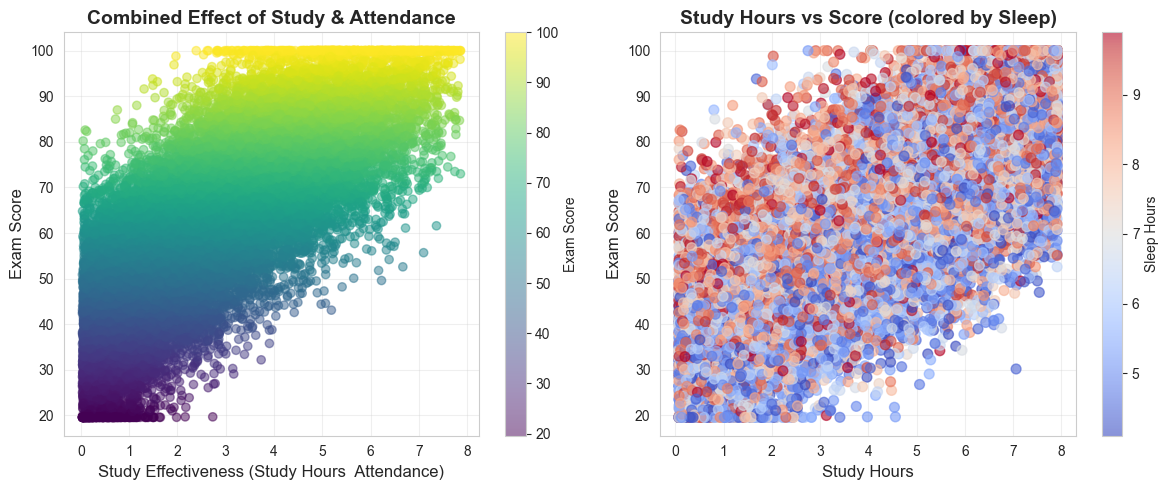

In [17]:
# Study hours effectiveness depends on attendance
df['study_effectiveness'] = df['study_hours'] * df['class_attendance'] / 100

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['study_effectiveness'], df['exam_score'], alpha=0.5, c=df['exam_score'], cmap='viridis')
plt.xlabel('Study Effectiveness (Study Hours  Attendance)', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.title('Combined Effect of Study & Attendance', fontsize=14, fontweight='bold')
plt.colorbar(label='Exam Score')
plt.grid(alpha=0.3)

# Sleep impact on study efficiency
plt.subplot(1, 2, 2)
scatter = plt.scatter(df['study_hours'], df['exam_score'], 
                     c=df['sleep_hours'], cmap='coolwarm', alpha=0.6, s=50)
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.title('Study Hours vs Score (colored by Sleep)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Sleep Hours')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Comprehensive summary
print("\n" + "="*60)
print("COMPREHENSIVE DATA SUMMARY REPORT")
print("="*60)

print(f"\nDataset Overview:")
print(f"   - Total students: {len(df):,}")
print(f"   - Features: {len(df.columns)}")
print(f"   - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nTarget Variable (Exam Score):")
print(f"   - Mean: {df['exam_score'].mean():.2f}")
print(f"   - Median: {df['exam_score'].median():.2f}")
print(f"   - Std:  {df['exam_score'].std():.2f}")

print(f"\nDemographics:")
print(f"   - Age range: {df['age'].min()}-{df['age'].max()}")
print(f"   - Most common course: {df['course'].mode()[0]}")
print(f"   - Gender distribution: {dict(df['gender'].value_counts())}")

print(f"\nStudy Patterns:")
print(f"   - Avg study hours: {df['study_hours'].mean():.2f}")
print(f"   - Avg attendance: {df['class_attendance']. mean():.1f}%")
print(f"   - Most popular study method: {df['study_method'].mode()[0]}")

print(f"\nSleep Patterns:")
print(f"   - Avg sleep hours: {df['sleep_hours'].mean():.2f}")
print(f"   - Good sleep quality: {(df['sleep_quality']=='good').sum()/len(df)*100:.1f}%")

print(f"\nKey Correlations with Exam Score:")
correlations = df.select_dtypes(include=['float64', 'int64']).corr()['exam_score'].drop('exam_score').sort_values(ascending=False)
for feature, corr in correlations.head(3).items():
    print(f"   - {feature}: {corr:.3f}")



COMPREHENSIVE DATA SUMMARY REPORT

Dataset Overview:
   - Total students: 20,000
   - Features: 14
   - Memory usage: 9.40 MB

Target Variable (Exam Score):
   - Mean: 62.51
   - Median: 62.60
   - Std:  18.91

Demographics:
   - Age range: 17-24
   - Most common course: bca
   - Gender distribution: {'male': np.int64(10062), 'female': np.int64(9938)}

Study Patterns:
   - Avg study hours: 4.01
   - Avg attendance: 70.0%
   - Most popular study method: self-study

Sleep Patterns:
   - Avg sleep hours: 7.01
   - Good sleep quality: 33.1%

Key Correlations with Exam Score:
   - study_effectiveness: 0.762
   - study_hours: 0.718
   - class_attendance: 0.309


 # Machine Learning Model Development



 ## Data Preparation



 Before building models, we need to prepare our data by:

 1. Defining features (X) and target variable (y)

 2. Separating numerical and categorical features

 3. Creating preprocessing pipelines

 4. Splitting data into training, validation, and test sets

In [19]:
# Reload data to ensure clean state
df = pd.read_csv('Exam_Score_Prediction_Modified.csv', index_col='student_id')

# Create study_effectiveness feature
df['study_effectiveness'] = df['study_hours'] * df['class_attendance'] / 100

# Define target and features
y = df["exam_score"]
X = df.drop(columns=["exam_score", "performance_category"], errors='ignore')

print("="*60)
print("DATA PREPARATION")
print("="*60)
print(f"Total samples: {len(X)}")
print(f"Total features: {X.shape[1]}")
print(f"Target variable: exam_score (range: {y.min():.1f} - {y.max():.1f})")


DATA PREPARATION
Total samples: 20000
Total features: 12
Target variable: exam_score (range: 19.6 - 100.0)


In [20]:
# Define feature types
numeric_features = [
    "age",
    "study_hours",
    "class_attendance",
    "sleep_hours",
    "study_effectiveness"
]

categorical_features = [
    "gender",
    "course",
    "internet_access",
    "sleep_quality",
    "study_method",
    "facility_rating",
    "exam_difficulty"
]

print(f"\nNumeric features ({len(numeric_features)}):")
for feat in numeric_features:
    print(f"   {feat}")

print(f"\nCategorical features ({len(categorical_features)}):")
for feat in categorical_features:
    print(f"   {feat} ({df[feat].nunique()} unique values)")



Numeric features (5):
   age
   study_hours
   class_attendance
   sleep_hours
   study_effectiveness

Categorical features (7):
   gender (2 unique values)
   course (7 unique values)
   internet_access (2 unique values)
   sleep_quality (3 unique values)
   study_method (5 unique values)
   facility_rating (3 unique values)
   exam_difficulty (3 unique values)


In [21]:
# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())  # Standardize numeric features (mean=0, std=1)
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))  # One-hot encode categories
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing Pipeline Created:")
print("   Numeric:  StandardScaler (standardization)")
print("   Categorical: OneHotEncoder (one-hot encoding, drop first to avoid multicollinearity)")



Preprocessing Pipeline Created:
   Numeric:  StandardScaler (standardization)
   Categorical: OneHotEncoder (one-hot encoding, drop first to avoid multicollinearity)


In [22]:
# Data Splitting:  70% Train, 15% Validation, 15% Test
print("\n" + "="*60)
print("DATA SPLITTING")
print("="*60)

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split: 15% validation, 15% test (from the 30% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"\nTraining set:    {X_train.shape[0]: ,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nTarget statistics:")
print(f"  Training   - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"  Validation - Mean: {y_val.mean():.2f}, Std: {y_val.std():.2f}")
print(f"  Test       - Mean: {y_test. mean():.2f}, Std: {y_test.std():.2f}")



DATA SPLITTING

Training set:     14,000 samples (70.0%)
Validation set: 3,000 samples (15.0%)
Test set:       3,000 samples (15.0%)

Target statistics:
  Training   - Mean: 62.54, Std: 18.87
  Validation - Mean: 62.09, Std: 19.06
  Test       - Mean: 62.82, Std: 18.94


 ---

 # Part 1: Linear Regression Models



 Linear regression models assume a linear relationship between features and the target variable.  We will compare four variants:



 1. **Ordinary Least Squares (OLS)** - Standard linear regression

 2. **Ridge Regression** - Adds L2 regularization to prevent overfitting

 3. **Lasso Regression** - Adds L1 regularization for feature selection

 4. **ElasticNet** - Combines L1 and L2 regularization



 ---

 ## 1.1 Ordinary Least Squares (OLS) Linear Regression



 **Model Overview:**

 - Finding the line that minimizes the sum of squared residuals

 - Formula: `y =  + x + x + ...  + x`

 - No regularization applied



 **Strengths:**

 - Simple and interpretable

 - Fast to train

 - Works well when features are not highly correlated



 **Weaknesses:**

 - Sensitive to multicollinearity

 - Can overfit if number of features is large

 - Assumes linear relationships

In [ ]:
# Train OLS Linear Regression
print("="*60)
print("TRAINING:  Ordinary Least Squares (OLS) Linear Regression")
print("="*60)

ols_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Cross-validation on training set (5-fold cross-validation (K-Fold CV)
cv_scores = cross_val_score(ols_model, X_train, y_train, cv=5, scoring="r2")
print(f"\n5-Fold Cross-Validation R Scores:")
print(f"  {cv_scores}")
print(f"  Mean: {cv_scores.mean():.4f} ({cv_scores.std():.4f})")

# Fit model
ols_model.fit(X_train, y_train)

# Predictions
y_train_pred_ols = ols_model. predict(X_train)
y_val_pred_ols = ols_model.predict(X_val)
y_test_pred_ols = ols_model.predict(X_test)

# Metrics
train_r2_ols = r2_score(y_train, y_train_pred_ols)
train_rmse_ols = np.sqrt(mean_squared_error(y_train, y_train_pred_ols))
train_mae_ols = mean_absolute_error(y_train, y_train_pred_ols)

val_r2_ols = r2_score(y_val, y_val_pred_ols)
val_rmse_ols = np.sqrt(mean_squared_error(y_val, y_val_pred_ols))
val_mae_ols = mean_absolute_error(y_val, y_val_pred_ols)

test_r2_ols = r2_score(y_test, y_test_pred_ols)
test_rmse_ols = np.sqrt(mean_squared_error(y_test, y_test_pred_ols))
test_mae_ols = mean_absolute_error(y_test, y_test_pred_ols)

print(f"\nPerformance Metrics:")
print(f"\n  Training Set:")
print(f"    R Score: {train_r2_ols:.4f}")
print(f"    RMSE:      {train_rmse_ols:.4f}")
print(f"    MAE:      {train_mae_ols:.4f}")

print(f"\n  Validation Set:")
print(f"    R Score: {val_r2_ols:.4f}")
print(f"    RMSE:     {val_rmse_ols:.4f}")
print(f"    MAE:      {val_mae_ols:.4f}")

print(f"\n  Test Set:")
print(f"    R Score: {test_r2_ols:.4f}")
print(f"    RMSE:      {test_rmse_ols:.4f}")
print(f"    MAE:      {test_mae_ols:.4f}")

# Feature coefficients
feature_names = ols_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = ols_model. named_steps["regressor"].coef_

coef_df_ols = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
}).sort_values(by="Abs_Coefficient", ascending=False)

print(f"\nTop 10 Most Important Features (by absolute coefficient):")
print(coef_df_ols.head(10)[["Feature", "Coefficient"]].to_string(index=False))


TRAINING:  Ordinary Least Squares (OLS) Linear Regression

5-Fold Cross-Validation R Scores:
  [0.72878453 0.72855324 0.72743002 0.73946379 0.72179723]
  Mean: 0.7292 (0.0057)

Performance Metrics:

  Training Set:
    R Score: 0.7303
    RMSE:      9.7983
    MAE:      7.8529

  Validation Set:
    R Score: 0.7350
    RMSE:     9.8108
    MAE:      7.8818

  Test Set:
    R Score: 0.7372
    RMSE:      9.7065
    MAE:      7.8350

Top 10 Most Important Features (by absolute coefficient):
                        Feature  Coefficient
               num__study_hours    13.972766
   cat__study_method_self-study    -9.631478
cat__study_method_online videos    -8.986866
  cat__study_method_group study    -7.900143
       cat__facility_rating_low    -7.783571
          num__class_attendance     6.101273
        cat__study_method_mixed    -5.078823
        cat__sleep_quality_poor    -4.692705
        cat__sleep_quality_good     4.568962
    cat__facility_rating_medium    -3.794722


 ## 1.2 Ridge Regression (L2 Regularization)



 **Model Overview:**

 - Adds L2 penalty term:  ` * ()` to the loss function

 - Shrinks coefficients towards zero but never exactly to zero

 - The hyperparameter  (alpha) controls regularization strength



 **Strengths:**

 - Handles multicollinearity better than OLS

 - Reduces overfitting by penalizing large coefficients

 - Keeps all features in the model



 **Weaknesses:**

 - Does not perform feature selection

 - Less interpretable than OLS

 - Requires hyperparameter tuning

In [24]:
# Train Ridge Regression
print("="*60)
print("TRAINING: Ridge Regression (L2 Regularization)")
print("="*60)

# Define range of alpha values to test
alphas = np.logspace(-3, 3, 50)  # 50 values from 0.001 to 1000

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RidgeCV(alphas=alphas, cv=5))  # Built-in cross-validation
])

# Fit model (RidgeCV automatically finds best alpha)
ridge_model.fit(X_train, y_train)

best_alpha_ridge = ridge_model.named_steps["regressor"].alpha_
print(f"\nBest alpha (via 5-fold CV): {best_alpha_ridge:.4f}")

# Predictions
y_train_pred_ridge = ridge_model.predict(X_train)
y_val_pred_ridge = ridge_model. predict(X_val)
y_test_pred_ridge = ridge_model.predict(X_test)

# Metrics
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
train_rmse_ridge = np. sqrt(mean_squared_error(y_train, y_train_pred_ridge))
train_mae_ridge = mean_absolute_error(y_train, y_train_pred_ridge)

val_r2_ridge = r2_score(y_val, y_val_pred_ridge)
val_rmse_ridge = np. sqrt(mean_squared_error(y_val, y_val_pred_ridge))
val_mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)

test_r2_ridge = r2_score(y_test, y_test_pred_ridge)
test_rmse_ridge = np. sqrt(mean_squared_error(y_test, y_test_pred_ridge))
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

print(f"\nPerformance Metrics:")
print(f"\n  Training Set:")
print(f"    R Score: {train_r2_ridge:.4f}")
print(f"    RMSE:     {train_rmse_ridge:.4f}")
print(f"    MAE:      {train_mae_ridge:.4f}")

print(f"\n  Validation Set:")
print(f"    R Score: {val_r2_ridge:.4f}")
print(f"    RMSE:     {val_rmse_ridge:.4f}")
print(f"    MAE:      {val_mae_ridge:.4f}")

print(f"\n  Test Set:")
print(f"    R Score:  {test_r2_ridge:.4f}")
print(f"    RMSE:     {test_rmse_ridge:.4f}")
print(f"    MAE:      {test_mae_ridge:.4f}")

# Feature coefficients
coefficients_ridge = ridge_model. named_steps["regressor"].coef_

coef_df_ridge = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients_ridge,
    "Abs_Coefficient": np.abs(coefficients_ridge)
}).sort_values(by="Abs_Coefficient", ascending=False)

print(f"\nTop 10 Most Important Features (by absolute coefficient):")
print(coef_df_ridge.head(10)[["Feature", "Coefficient"]].to_string(index=False))


TRAINING: Ridge Regression (L2 Regularization)

Best alpha (via 5-fold CV): 1.5264

Performance Metrics:

  Training Set:
    R Score: 0.7303
    RMSE:     9.7983
    MAE:      7.8531

  Validation Set:
    R Score: 0.7350
    RMSE:     9.8104
    MAE:      7.8814

  Test Set:
    R Score:  0.7372
    RMSE:     9.7064
    MAE:      7.8350

Top 10 Most Important Features (by absolute coefficient):
                        Feature  Coefficient
               num__study_hours    13.939782
   cat__study_method_self-study    -9.609430
cat__study_method_online videos    -8.964799
  cat__study_method_group study    -7.878527
       cat__facility_rating_low    -7.776959
          num__class_attendance     6.087163
        cat__study_method_mixed    -5.058943
        cat__sleep_quality_poor    -4.691231
        cat__sleep_quality_good     4.567509
    cat__facility_rating_medium    -3.789395


 ## 1.3 Lasso Regression (L1 Regularization)



 **Model Overview:**

 - Adds L1 penalty term: ` * ||` to the loss function

 - Can shrink coefficients exactly to zero, performing automatic feature selection

 - The hyperparameter  controls regularization strength



 **Strengths:**

 - Performs automatic feature selection

 - Creates sparse models (many coefficients = 0)

 - Good for high-dimensional data

 - Improves interpretability



 **Weaknesses:**

 - May arbitrarily select one feature among correlated features

 - Can be unstable with highly correlated features

 - Requires hyperparameter tuning

In [25]:
# Train Lasso Regression
print("="*60)
print("TRAINING: Lasso Regression (L1 Regularization)")
print("="*60)

lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LassoCV(alphas=alphas, cv=5, max_iter=10000))
])

# Fit model
lasso_model.fit(X_train, y_train)

best_alpha_lasso = lasso_model.named_steps["regressor"].alpha_
print(f"\nBest alpha (via 5-fold CV): {best_alpha_lasso:.4f}")

# Predictions
y_train_pred_lasso = lasso_model.predict(X_train)
y_val_pred_lasso = lasso_model. predict(X_val)
y_test_pred_lasso = lasso_model.predict(X_test)

# Metrics
train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
train_mae_lasso = mean_absolute_error(y_train, y_train_pred_lasso)

val_r2_lasso = r2_score(y_val, y_val_pred_lasso)
val_rmse_lasso = np.sqrt(mean_squared_error(y_val, y_val_pred_lasso))
val_mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)

test_r2_lasso = r2_score(y_test, y_test_pred_lasso)
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
test_mae_lasso = mean_absolute_error(y_test, y_test_pred_lasso)

print(f"\nPerformance Metrics:")
print(f"\n  Training Set:")
print(f"    R Score: {train_r2_lasso:.4f}")
print(f"    RMSE:     {train_rmse_lasso:.4f}")
print(f"    MAE:      {train_mae_lasso:.4f}")

print(f"\n  Validation Set:")
print(f"    R Score: {val_r2_lasso:.4f}")
print(f"    RMSE:     {val_rmse_lasso:.4f}")
print(f"    MAE:      {val_mae_lasso:.4f}")

print(f"\n  Test Set:")
print(f"    R Score: {test_r2_lasso:.4f}")
print(f"    RMSE:      {test_rmse_lasso:.4f}")
print(f"    MAE:      {test_mae_lasso:.4f}")

# Feature selection analysis
coefficients_lasso = lasso_model.named_steps["regressor"].coef_
non_zero_features = np.sum(coefficients_lasso != 0)
total_features = len(coefficients_lasso)

print(f"\nFeature Selection:")
print(f"  Total features: {total_features}")
print(f"  Non-zero features: {non_zero_features}")
print(f"  Features set to zero: {total_features - non_zero_features}")
print(f"  Sparsity: {(1 - non_zero_features/total_features)*100:.1f}%")

coef_df_lasso = pd.DataFrame({
    "Feature":  feature_names,
    "Coefficient": coefficients_lasso,
    "Abs_Coefficient": np.abs(coefficients_lasso)
}).sort_values(by="Abs_Coefficient", ascending=False)

# Show only non-zero coefficients
non_zero_coefs = coef_df_lasso[coef_df_lasso["Coefficient"] != 0]
print(f"\nTop 10 Selected Features (non-zero coefficients):")
print(non_zero_coefs. head(10)[["Feature", "Coefficient"]].to_string(index=False))


TRAINING: Lasso Regression (L1 Regularization)

Best alpha (via 5-fold CV): 0.0168

Performance Metrics:

  Training Set:
    R Score: 0.7302
    RMSE:     9.8013
    MAE:      7.8572

  Validation Set:
    R Score: 0.7355
    RMSE:     9.8002
    MAE:      7.8746

  Test Set:
    R Score: 0.7373
    RMSE:      9.7043
    MAE:      7.8347

Feature Selection:
  Total features: 23
  Non-zero features: 14
  Features set to zero: 9
  Sparsity: 39.1%

Top 10 Selected Features (non-zero coefficients):
                        Feature  Coefficient
               num__study_hours    13.498835
   cat__study_method_self-study    -9.216748
cat__study_method_online videos    -8.566711
       cat__facility_rating_low    -7.627391
  cat__study_method_group study    -7.474157
          num__class_attendance     5.889667
        cat__study_method_mixed    -4.656422
        cat__sleep_quality_poor    -4.641358
        cat__sleep_quality_good     4.518732
    cat__facility_rating_medium    -3.637039


 ## 1.4 ElasticNet Regression (L1 + L2 Regularization)



 **Model Overview:**

 - Combines L1 and L2 penalties: ` * (l1_ratio * || + (1-l1_ratio) * ())`

 - Has two hyperparameters:  (overall strength) and l1_ratio (balance between L1 and L2)

 - l1_ratio = 1 is pure Lasso, l1_ratio = 0 is pure Ridge



 **Strengths:**

 - Combines benefits of Ridge and Lasso

 - Better handles correlated features than Lasso alone

 - Performs feature selection while maintaining stability

 - Flexible regularization



 **Weaknesses:**

 - Two hyperparameters to tune

 - More computationally expensive

 - Can be harder to interpret than pure L1 or L2

In [26]:
# Train ElasticNet Regression
print("="*60)
print("TRAINING: ElasticNet Regression (L1 + L2 Regularization)")
print("="*60)

elastic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", ElasticNetCV(
        alphas=alphas,
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],  # Test different L1/L2 balances
        cv=5,
        max_iter=10000
    ))
])

# Fit model
elastic_model. fit(X_train, y_train)

best_alpha_elastic = elastic_model.named_steps["regressor"].alpha_
best_l1_ratio = elastic_model.named_steps["regressor"].l1_ratio_

print(f"\nBest hyperparameters (via 5-fold CV):")
print(f"  Alpha:     {best_alpha_elastic:.4f}")
print(f"  L1 ratio: {best_l1_ratio:.4f} ({best_l1_ratio*100:.0f}% L1, {(1-best_l1_ratio)*100:.0f}% L2)")

# Predictions
y_train_pred_elastic = elastic_model.predict(X_train)
y_val_pred_elastic = elastic_model. predict(X_val)
y_test_pred_elastic = elastic_model.predict(X_test)

# Metrics
train_r2_elastic = r2_score(y_train, y_train_pred_elastic)
train_rmse_elastic = np. sqrt(mean_squared_error(y_train, y_train_pred_elastic))
train_mae_elastic = mean_absolute_error(y_train, y_train_pred_elastic)

val_r2_elastic = r2_score(y_val, y_val_pred_elastic)
val_rmse_elastic = np. sqrt(mean_squared_error(y_val, y_val_pred_elastic))
val_mae_elastic = mean_absolute_error(y_val, y_val_pred_elastic)

test_r2_elastic = r2_score(y_test, y_test_pred_elastic)
test_rmse_elastic = np. sqrt(mean_squared_error(y_test, y_test_pred_elastic))
test_mae_elastic = mean_absolute_error(y_test, y_test_pred_elastic)

print(f"\nPerformance Metrics:")
print(f"\n  Training Set:")
print(f"    R Score: {train_r2_elastic:.4f}")
print(f"    RMSE:     {train_rmse_elastic:.4f}")
print(f"    MAE:      {train_mae_elastic:.4f}")

print(f"\n  Validation Set:")
print(f"    R Score: {val_r2_elastic:.4f}")
print(f"    RMSE:     {val_rmse_elastic:.4f}")
print(f"    MAE:      {val_mae_elastic:.4f}")

print(f"\n  Test Set:")
print(f"    R Score:  {test_r2_elastic:.4f}")
print(f"    RMSE:     {test_rmse_elastic:.4f}")
print(f"    MAE:      {test_mae_elastic:.4f}")

# Feature selection analysis
coefficients_elastic = elastic_model.named_steps["regressor"].coef_
non_zero_features_elastic = np.sum(coefficients_elastic != 0)

print(f"\nFeature Selection:")
print(f"  Total features: {len(coefficients_elastic)}")
print(f"  Non-zero features: {non_zero_features_elastic}")
print(f"  Features set to zero: {len(coefficients_elastic) - non_zero_features_elastic}")
print(f"  Sparsity: {(1 - non_zero_features_elastic/len(coefficients_elastic))*100:.1f}%")

coef_df_elastic = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients_elastic,
    "Abs_Coefficient": np.abs(coefficients_elastic)
}).sort_values(by="Abs_Coefficient", ascending=False)

non_zero_coefs_elastic = coef_df_elastic[coef_df_elastic["Coefficient"] != 0]
print(f"\nTop 10 Selected Features (non-zero coefficients):")
print(non_zero_coefs_elastic.head(10)[["Feature", "Coefficient"]].to_string(index=False))


TRAINING: ElasticNet Regression (L1 + L2 Regularization)

Best hyperparameters (via 5-fold CV):
  Alpha:     0.0095
  L1 ratio: 0.9000 (90% L1, 10% L2)

Performance Metrics:

  Training Set:
    R Score: 0.7302
    RMSE:     9.8007
    MAE:      7.8569

  Validation Set:
    R Score: 0.7354
    RMSE:     9.8022
    MAE:      7.8757

  Test Set:
    R Score:  0.7373
    RMSE:     9.7053
    MAE:      7.8356

Feature Selection:
  Total features: 23
  Non-zero features: 17
  Features set to zero: 6
  Sparsity: 26.1%

Top 10 Selected Features (non-zero coefficients):
                        Feature  Coefficient
               num__study_hours    13.494537
   cat__study_method_self-study    -9.234986
cat__study_method_online videos    -8.586992
       cat__facility_rating_low    -7.647408
  cat__study_method_group study    -7.501018
          num__class_attendance     5.891895
        cat__study_method_mixed    -4.696925
        cat__sleep_quality_poor    -4.653521
        cat__sleep_qualit

 ## 1.5 Comparison of All Linear Models

In [27]:
# Create comparison dataframe
print("="*60)
print("LINEAR MODELS COMPARISON")
print("="*60)

linear_models_comparison = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "ElasticNet"],
    "Train R": [train_r2_ols, train_r2_ridge, train_r2_lasso, train_r2_elastic],
    "Val R": [val_r2_ols, val_r2_ridge, val_r2_lasso, val_r2_elastic],
    "Test R": [test_r2_ols, test_r2_ridge, test_r2_lasso, test_r2_elastic],
    "Train RMSE": [train_rmse_ols, train_rmse_ridge, train_rmse_lasso, train_rmse_elastic],
    "Val RMSE": [val_rmse_ols, val_rmse_ridge, val_rmse_lasso, val_rmse_elastic],
    "Test RMSE": [test_rmse_ols, test_rmse_ridge, test_rmse_lasso, test_rmse_elastic],
    "Test MAE": [test_mae_ols, test_mae_ridge, test_mae_lasso, test_mae_elastic],
    "Features Used": [
        len(feature_names),
        len(feature_names),
        non_zero_features,
        non_zero_features_elastic
    ]
})

print("\nPerformance Metrics:")
print(linear_models_comparison. to_string(index=False))

# Hyperparameters
print("\n\nHyperparameters:")
hyper_df = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "ElasticNet"],
    "Alpha ()": [best_alpha_ridge, best_alpha_lasso, best_alpha_elastic],
    "L1 Ratio":  ["N/A", "1.0 (pure L1)", f"{best_l1_ratio:.2f}"]
})
print(hyper_df.to_string(index=False))

# Check for overfitting
print("\n\nOverfitting Analysis (Train R - Test R):")
for idx, row in linear_models_comparison.iterrows():
    diff = row["Train R"] - row["Test R"]
    status = "Good" if diff < 0.02 else ("Moderate" if diff < 0.05 else "Overfitting")
    print(f"{row['Model']:12s}:{diff:+.4f}[{status}]")


LINEAR MODELS COMPARISON

Performance Metrics:
     Model  Train R    Val R   Test R  Train RMSE  Val RMSE  Test RMSE  Test MAE  Features Used
       OLS 0.730344 0.734975 0.737189    9.798272  9.810784   9.706471  7.835014             23
     Ridge 0.730343 0.734998 0.737194    9.798279  9.810352   9.706381  7.835021             23
     Lasso 0.730179 0.735547 0.737305    9.801258  9.800188   9.704331  7.834697             14
ElasticNet 0.730210 0.735436 0.737252    9.800698  9.802245   9.705315  7.835568             17


Hyperparameters:
     Model  Alpha ()      L1 Ratio
     Ridge  1.526418           N/A
     Lasso  0.016768 1.0 (pure L1)
ElasticNet  0.009541          0.90


Overfitting Analysis (Train R - Test R):
OLS         :-0.0068[Good]
Ridge       :-0.0069[Good]
Lasso       :-0.0071[Good]
ElasticNet  :-0.0070[Good]


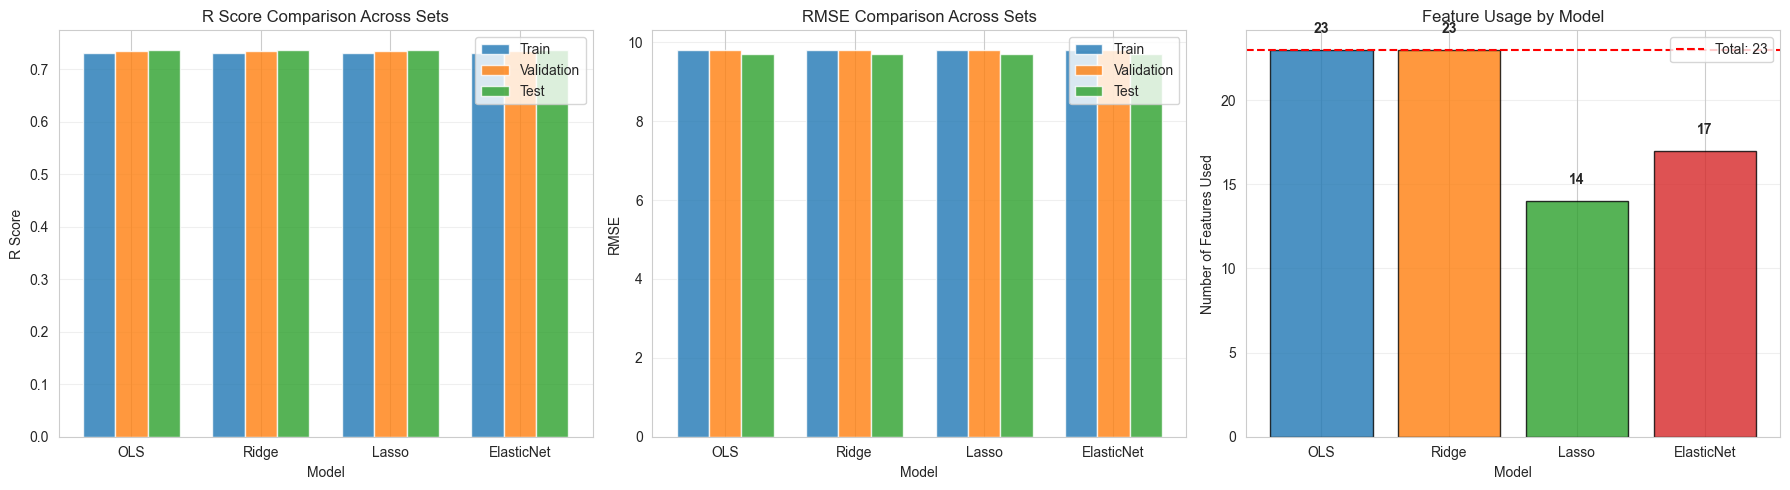

In [ ]:
# Visualizing comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R comparison
ax1 = axes[0]
x = np.arange(len(linear_models_comparison))
width = 0.25
ax1.bar(x - width, linear_models_comparison["Train R"], width, label='Train', alpha=0.8)
ax1.bar(x, linear_models_comparison["Val R"], width, label='Validation', alpha=0.8)
ax1.bar(x + width, linear_models_comparison["Test R"], width, label='Test', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('R Score')
ax1.set_title('R Score Comparison Across Sets')
ax1.set_xticks(x)
ax1.set_xticklabels(linear_models_comparison["Model"])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# RMSE comparison
ax2 = axes[1]
ax2.bar(x - width, linear_models_comparison["Train RMSE"], width, label='Train', alpha=0.8)
ax2.bar(x, linear_models_comparison["Val RMSE"], width, label='Validation', alpha=0.8)
ax2.bar(x + width, linear_models_comparison["Test RMSE"], width, label='Test', alpha=0.8)
ax2.set_xlabel('Model')
ax2.set_ylabel('RMSE')
ax2.set_title('RMSE Comparison Across Sets')
ax2.set_xticks(x)
ax2.set_xticklabels(linear_models_comparison["Model"])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Feature usage
ax3 = axes[2]
colors_feat = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax3.bar(linear_models_comparison["Model"], linear_models_comparison["Features Used"], color=colors_feat, alpha=0.8, edgecolor='black')
ax3.set_xlabel('Model')
ax3.set_ylabel('Number of Features Used')
ax3.set_title('Feature Usage by Model')
ax3.axhline(len(feature_names), color='red', linestyle='--', label=f'Total: {len(feature_names)}')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

for i, v in enumerate(linear_models_comparison["Features Used"]):
    ax3.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



COEFFICIENT COMPARISON - Top 15 Features
                        Feature       OLS     Ridge     Lasso  ElasticNet
               num__study_hours 13.972766 13.939782 13.498835   13.494537
   cat__study_method_self-study -9.631478 -9.609430 -9.216748   -9.234986
cat__study_method_online videos -8.986866 -8.964799 -8.566711   -8.586992
  cat__study_method_group study -7.900143 -7.878527 -7.474157   -7.501018
       cat__facility_rating_low -7.783571 -7.776959 -7.627391   -7.647408
          num__class_attendance  6.101273  6.087163  5.889667    5.891895
        cat__study_method_mixed -5.078823 -5.058943 -4.656422   -4.696925
        cat__sleep_quality_poor -4.692705 -4.691231 -4.641358   -4.653521
        cat__sleep_quality_good  4.568962  4.567509  4.518732    4.530070
    cat__facility_rating_medium -3.794722 -3.789395 -3.637039   -3.668602
               num__sleep_hours  2.499760  2.499418  2.481769    2.487450
       num__study_effectiveness -0.508315 -0.473299 -0.000000    0.000

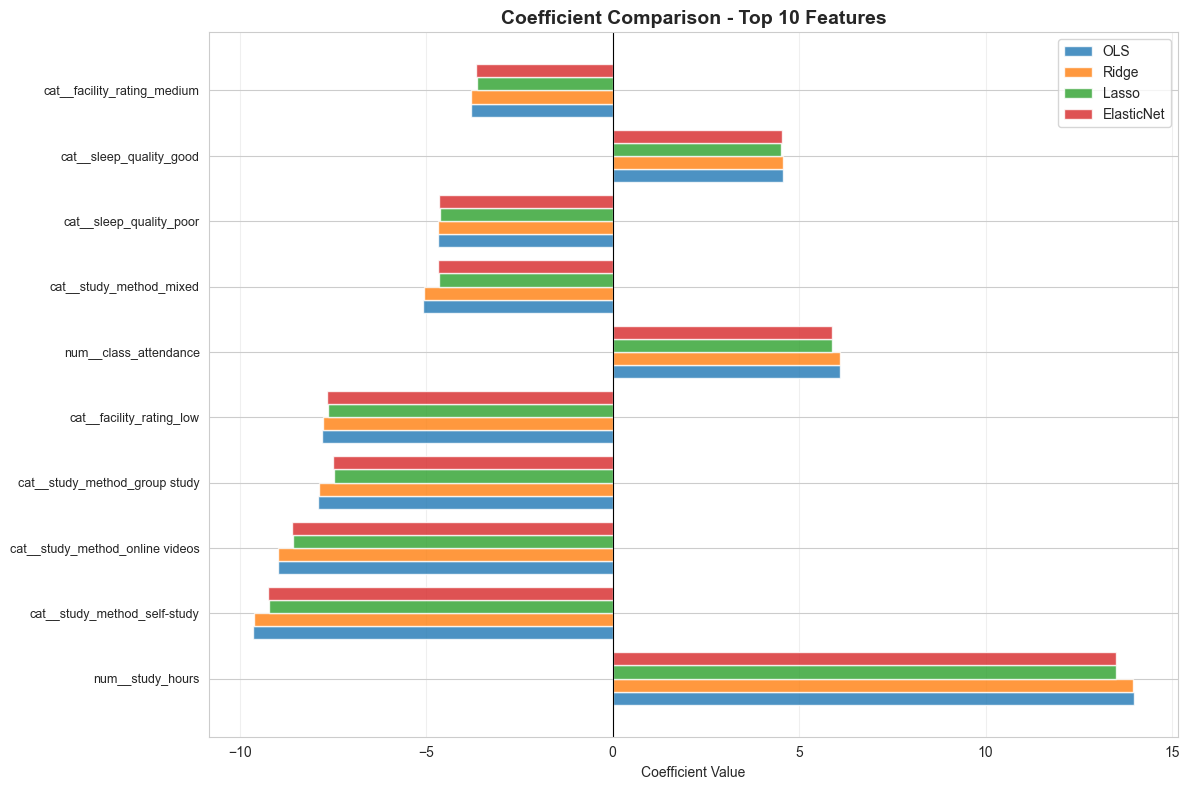

In [29]:
# Coefficient comparison for top features
coef_comparison = pd.DataFrame({
    "Feature": feature_names,
    "OLS": ols_model.named_steps["regressor"]. coef_,
    "Ridge": ridge_model.named_steps["regressor"].coef_,
    "Lasso": lasso_model.named_steps["regressor"].coef_,
    "ElasticNet": elastic_model.named_steps["regressor"].coef_
})

# Add absolute value for sorting
coef_comparison["Abs_OLS"] = np.abs(coef_comparison["OLS"])
coef_comparison = coef_comparison.sort_values("Abs_OLS", ascending=False).drop(columns="Abs_OLS")

print("\n" + "="*60)
print("COEFFICIENT COMPARISON - Top 15 Features")
print("="*60)
print(coef_comparison.head(15).to_string(index=False))

# Visualize coefficient comparison for top 10 features
top10_coef = coef_comparison.head(10)

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(top10_coef))
width = 0.2

ax.barh(x - 1.5*width, top10_coef["OLS"], width, label='OLS', alpha=0.8)
ax.barh(x - 0.5*width, top10_coef["Ridge"], width, label='Ridge', alpha=0.8)
ax.barh(x + 0.5*width, top10_coef["Lasso"], width, label='Lasso', alpha=0.8)
ax.barh(x + 1.5*width, top10_coef["ElasticNet"], width, label='ElasticNet', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(top10_coef["Feature"], fontsize=9)
ax.set_xlabel('Coefficient Value')
ax.set_title('Coefficient Comparison - Top 10 Features', fontsize=14, fontweight='bold')
ax.legend()
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


 ---

 # Part 2: Non-Linear Regression Models



 Non-linear models can capture complex patterns that linear models cannot. We will evaluate:



 1. **Decision Tree Regressor** - Tree-based model with decision rules

 2. **Random Forest Regressor** - Ensemble of decision trees

 3. **Support Vector Regression (SVR)** - Uses kernel functions to map to higher dimensions



 ---

 ## 2.1 Decision Tree Regressor



 **Model Overview:**

 - Creates a tree structure where each node represents a decision based on a feature value

 - Splits data recursively to minimize variance in target variable

 - Makes predictions by averaging values in leaf nodes



 **Strengths:**

 - Captures non-linear relationships and interactions automatically

 - No need for feature scaling

 - Easy to visualize and interpret

 - Handles mixed data types well



 **Weaknesses:**

 - Highly prone to overfitting

 - Unstable (small data changes can create very different trees)

 - Cannot extrapolate beyond training data range

 - Biased towards features with more levels

In [30]:
# Train Decision Tree Regressor
print("="*60)
print("TRAINING: Decision Tree Regressor")
print("="*60)

dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42, max_depth=10))
])

# Fit model
dt_model. fit(X_train, y_train)

# Predictions
y_train_pred_dt = dt_model.predict(X_train)
y_val_pred_dt = dt_model.predict(X_val)
y_test_pred_dt = dt_model.predict(X_test)

# Metrics
train_r2_dt = r2_score(y_train, y_train_pred_dt)
train_rmse_dt = np. sqrt(mean_squared_error(y_train, y_train_pred_dt))
train_mae_dt = mean_absolute_error(y_train, y_train_pred_dt)

val_r2_dt = r2_score(y_val, y_val_pred_dt)
val_rmse_dt = np. sqrt(mean_squared_error(y_val, y_val_pred_dt))
val_mae_dt = mean_absolute_error(y_val, y_val_pred_dt)

test_r2_dt = r2_score(y_test, y_test_pred_dt)
test_rmse_dt = np. sqrt(mean_squared_error(y_test, y_test_pred_dt))
test_mae_dt = mean_absolute_error(y_test, y_test_pred_dt)

print(f"\nHyperparameters:")
print(f"  Max depth: {dt_model.named_steps['regressor'].max_depth}")
print(f"  Random state: {dt_model.named_steps['regressor'].random_state}")

print(f"\nPerformance Metrics:")
print(f"\n  Training Set:")
print(f"    R Score: {train_r2_dt:.4f}")
print(f"    RMSE:     {train_rmse_dt:.4f}")
print(f"    MAE:      {train_mae_dt:.4f}")

print(f"\n  Validation Set:")
print(f"    R Score: {val_r2_dt:.4f}")
print(f"    RMSE:     {val_rmse_dt:.4f}")
print(f"    MAE:      {val_mae_dt:.4f}")

print(f"\n  Test Set:")
print(f"    R Score: {test_r2_dt:.4f}")
print(f"    RMSE:     {test_rmse_dt:.4f}")
print(f"    MAE:      {test_mae_dt:.4f}")

# Feature importance
feature_importance_dt = dt_model.named_steps["regressor"].feature_importances_
feat_imp_df_dt = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance_dt
}).sort_values(by="Importance", ascending=False)

print(f"\nTop 10 Most Important Features:")
print(feat_imp_df_dt.head(10).to_string(index=False))

# Overfitting check
overfit_diff_dt = train_r2_dt - test_r2_dt
print(f"\nOverfitting Analysis:")
print(f"Train R - Test R: {overfit_diff_dt:+.4f}")
if overfit_diff_dt > 0.1:
    print(f"  Status:   SIGNIFICANT OVERFITTING")
elif overfit_diff_dt > 0.05:
    print(f"  Status:   Moderate overfitting")
else:
    print(f"  Status:  Good generalization")


TRAINING: Decision Tree Regressor

Hyperparameters:
  Max depth: 10
  Random state: 42

Performance Metrics:

  Training Set:
    R Score: 0.7740
    RMSE:     8.9694
    MAE:      7.0009

  Validation Set:
    R Score: 0.5988
    RMSE:     12.0707
    MAE:      9.5777

  Test Set:
    R Score: 0.6035
    RMSE:     11.9217
    MAE:      9.4911

Top 10 Most Important Features:
                     Feature  Importance
    num__study_effectiveness    0.779563
            num__sleep_hours    0.037184
       num__class_attendance    0.035806
     cat__sleep_quality_poor    0.029998
    cat__facility_rating_low    0.026056
     cat__sleep_quality_good    0.020746
            num__study_hours    0.020734
cat__study_method_self-study    0.010163
                    num__age    0.008373
 cat__facility_rating_medium    0.006289

Overfitting Analysis:
Train R - Test R: +0.1705
  Status:   SIGNIFICANT OVERFITTING


 ## 2.2 Random Forest Regressor



 **Model Overview:**

 - Ensemble method that builds multiple decision trees on random subsets of data

 - Each tree uses random subsets of features at each split (feature bagging)

 - Final prediction is the average of all trees' predictions



 **Strengths:**

 - Significantly reduces overfitting compared to single decision trees

 - Very accurate on most datasets

 - Provides robust feature importance rankings

 - Handles non-linear relationships and feature interactions well

 - Less sensitive to hyperparameters than single trees



 **Weaknesses:**

 - Less interpretable than single decision trees

 - Slower to train and predict than linear models

 - Cannot extrapolate beyond training data range

 - Requires more memory

In [31]:
# Train Random Forest Regressor
print("="*60)
print("TRAINING: Random Forest Regressor")
print("="*60)

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1  # Use all CPU cores
    ))
])

# Fit model
rf_model. fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

# Metrics
train_r2_rf = r2_score(y_train, y_train_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)

val_r2_rf = r2_score(y_val, y_val_pred_rf)
val_rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
val_mae_rf = mean_absolute_error(y_val, y_val_pred_rf)

test_r2_rf = r2_score(y_test, y_test_pred_rf)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)

print(f"\nHyperparameters:")
print(f"  Number of trees: {rf_model. named_steps['regressor'].n_estimators}")
print(f"  Max depth: {rf_model.named_steps['regressor'].max_depth}")
print(f"  Min samples split: {rf_model. named_steps['regressor'].min_samples_split}")
print(f"  Min samples leaf: {rf_model.named_steps['regressor'].min_samples_leaf}")

print(f"\nPerformance Metrics:")
print(f"\n  Training Set:")
print(f"    R Score: {train_r2_rf:.4f}")
print(f"    RMSE:     {train_rmse_rf:.4f}")
print(f"    MAE:      {train_mae_rf:.4f}")

print(f"\n  Validation Set:")
print(f"    R Score: {val_r2_rf:.4f}")
print(f"    RMSE:      {val_rmse_rf:.4f}")
print(f"    MAE:      {val_mae_rf:.4f}")

print(f"\n  Test Set:")
print(f"    R Score: {test_r2_rf:.4f}")
print(f"    RMSE:     {test_rmse_rf:.4f}")
print(f"    MAE:      {test_mae_rf:.4f}")

# Feature importance
feature_importance_rf = rf_model. named_steps["regressor"].feature_importances_
feat_imp_df_rf = pd.DataFrame({
    "Feature": feature_names,
    "Importance":  feature_importance_rf
}).sort_values(by="Importance", ascending=False)

print(f"\nTop 10 Most Important Features:")
print(feat_imp_df_rf.head(10).to_string(index=False))

# Overfitting check
overfit_diff_rf = train_r2_rf - test_r2_rf
print(f"\nOverfitting Analysis:")
print(f"  Train R - Test R: {overfit_diff_rf:+.4f}")
if overfit_diff_rf > 0.1:
    print(f"  Status:   SIGNIFICANT OVERFITTING")
elif overfit_diff_rf > 0.05:
    print(f"  Status:   Moderate overfitting")
else:
    print(f"  Status:  Good generalization")


TRAINING: Random Forest Regressor

Hyperparameters:
  Number of trees: 100
  Max depth: 15
  Min samples split: 5
  Min samples leaf: 2

Performance Metrics:

  Training Set:
    R Score: 0.9127
    RMSE:     5.5744
    MAE:      4.3815

  Validation Set:
    R Score: 0.6994
    RMSE:      10.4485
    MAE:      8.4026

  Test Set:
    R Score: 0.6995
    RMSE:     10.3795
    MAE:      8.4173

Top 10 Most Important Features:
                        Feature  Importance
       num__study_effectiveness    0.675691
               num__sleep_hours    0.058462
          num__class_attendance    0.054803
               num__study_hours    0.041286
        cat__sleep_quality_poor    0.023136
       cat__facility_rating_low    0.022859
                       num__age    0.022050
        cat__sleep_quality_good    0.020818
   cat__study_method_self-study    0.011503
cat__study_method_online videos    0.009054

Overfitting Analysis:
  Train R - Test R: +0.2132
  Status:   SIGNIFICANT OVERFITTING


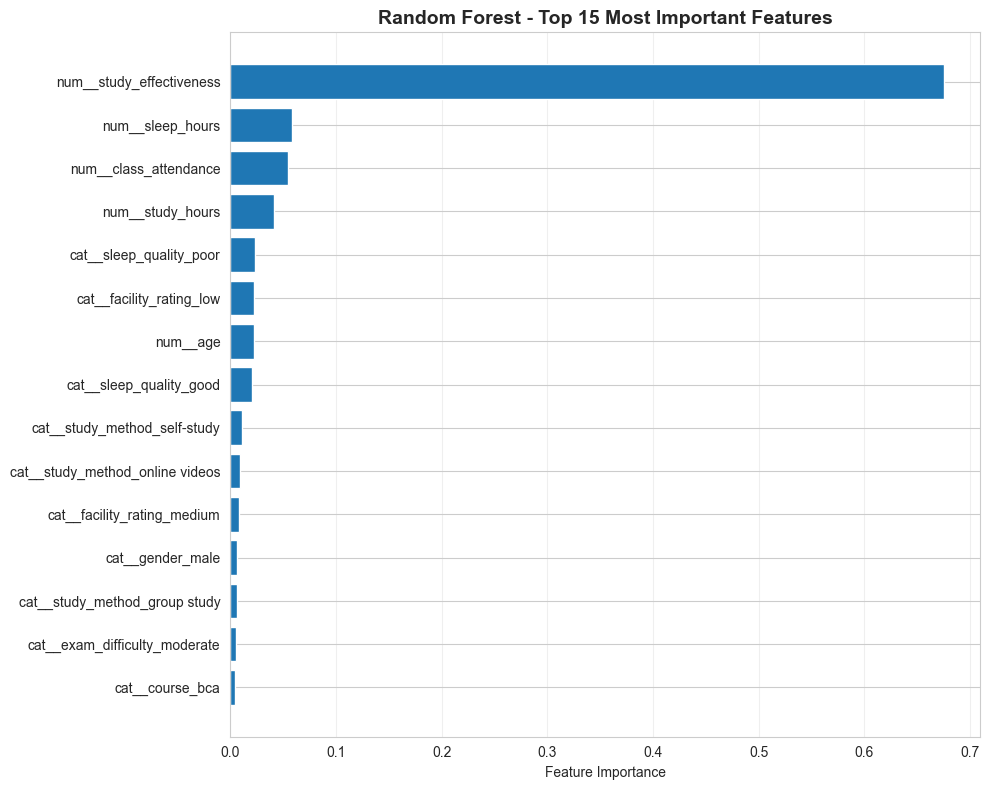

In [32]:
# Visualize Random Forest feature importance
plt. figure(figsize=(10, 8))
top_15_features = feat_imp_df_rf.head(15)
plt.barh(range(len(top_15_features)), top_15_features["Importance"])
plt.yticks(range(len(top_15_features)), top_15_features["Feature"])
plt.xlabel('Feature Importance')
plt.title('Random Forest - Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


 ## 2.3 Support Vector Regression (SVR)



 **Model Overview:**

 - Finds a hyperplane that fits the data within a margin of tolerance (epsilon)

 - Uses kernel functions to transform data into higher dimensions

 - RBF (Radial Basis Function) kernel captures non-linear patterns



 **Strengths:**

 - Effective in high-dimensional spaces

 - Memory efficient (uses subset of training points called support vectors)

 - Robust to outliers

 - Can model complex non-linear relationships with appropriate kernel



 **Weaknesses:**

 - Computationally expensive on large datasets

 - Requires careful hyperparameter tuning (C, epsilon, gamma)

 - Less interpretable than tree-based models

 - Sensitive to feature scaling (requires standardization)

In [33]:
# Train Support Vector Regression
print("="*60)
print("TRAINING: Support Vector Regression (SVR)")
print("="*60)

svr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", SVR(kernel='rbf', C=100, epsilon=0.1, gamma='scale'))
])

# Fit model
print("\nTraining SVR...  (this may take a while on large datasets)")
svr_model. fit(X_train, y_train)
print("Training complete!")

# Predictions
y_train_pred_svr = svr_model.predict(X_train)
y_val_pred_svr = svr_model.predict(X_val)
y_test_pred_svr = svr_model.predict(X_test)

# Metrics
train_r2_svr = r2_score(y_train, y_train_pred_svr)
train_rmse_svr = np.sqrt(mean_squared_error(y_train, y_train_pred_svr))
train_mae_svr = mean_absolute_error(y_train, y_train_pred_svr)

val_r2_svr = r2_score(y_val, y_val_pred_svr)
val_rmse_svr = np.sqrt(mean_squared_error(y_val, y_val_pred_svr))
val_mae_svr = mean_absolute_error(y_val, y_val_pred_svr)

test_r2_svr = r2_score(y_test, y_test_pred_svr)
test_rmse_svr = np.sqrt(mean_squared_error(y_test, y_test_pred_svr))
test_mae_svr = mean_absolute_error(y_test, y_test_pred_svr)

print(f"\nHyperparameters:")
print(f"  Kernel: {svr_model.named_steps['regressor'].kernel}")
print(f"  C (regularization): {svr_model.named_steps['regressor'].C}")
print(f"  Epsilon:  {svr_model.named_steps['regressor'].epsilon}")
print(f"  Gamma:  {svr_model.named_steps['regressor'].gamma}")

print(f"\nPerformance Metrics:")
print(f"\n  Training Set:")
print(f"    R Score: {train_r2_svr:.4f}")
print(f"    RMSE:     {train_rmse_svr:.4f}")
print(f"    MAE:      {train_mae_svr:.4f}")

print(f"\n  Validation Set:")
print(f"    R Score: {val_r2_svr:.4f}")
print(f"    RMSE:     {val_rmse_svr:.4f}")
print(f"    MAE:       {val_mae_svr:.4f}")

print(f"\n  Test Set:")
print(f"    R Score:  {test_r2_svr:.4f}")
print(f"    RMSE:     {test_rmse_svr:.4f}")
print(f"    MAE:      {test_mae_svr:.4f}")

# Overfitting check
overfit_diff_svr = train_r2_svr - test_r2_svr
print(f"\nOverfitting Analysis:")
print(f"  Train R - Test R: {overfit_diff_svr:+.4f}")
if overfit_diff_svr > 0.1:
    print(f"  Status:   SIGNIFICANT OVERFITTING")
elif overfit_diff_svr > 0.05:
    print(f"  Status:    Moderate overfitting")
else:
    print(f"  Status:   Good generalization")


TRAINING: Support Vector Regression (SVR)

Training SVR...  (this may take a while on large datasets)
Training complete!

Hyperparameters:
  Kernel: rbf
  C (regularization): 100
  Epsilon:  0.1
  Gamma:  scale

Performance Metrics:

  Training Set:
    R Score: 0.8140
    RMSE:     8.1386
    MAE:      5.5194

  Validation Set:
    R Score: 0.6826
    RMSE:     10.7367
    MAE:       8.5904

  Test Set:
    R Score:  0.6864
    RMSE:     10.6026
    MAE:      8.5447

Overfitting Analysis:
  Train R - Test R: +0.1275
  Status:   SIGNIFICANT OVERFITTING


 ## 2.4 Comparison of Non-Linear Models

In [34]:
# Create comparison dataframe for non-linear models
print("="*60)
print("NON-LINEAR MODELS COMPARISON")
print("="*60)

nonlinear_models_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "SVR"],
    "Train R": [train_r2_dt, train_r2_rf, train_r2_svr],
    "Val R": [val_r2_dt, val_r2_rf, val_r2_svr],
    "Test R": [test_r2_dt, test_r2_rf, test_r2_svr],
    "Train RMSE": [train_rmse_dt, train_rmse_rf, train_rmse_svr],
    "Val RMSE": [val_rmse_dt, val_rmse_rf, val_rmse_svr],
    "Test RMSE": [test_rmse_dt, test_rmse_rf, test_rmse_svr],
    "Test MAE": [test_mae_dt, test_mae_rf, test_mae_svr]
})

print("\nPerformance Metrics:")
print(nonlinear_models_comparison. to_string(index=False))

# Overfitting analysis
print("\n\nOverfitting Analysis (Train R - Test R):")
for idx, row in nonlinear_models_comparison.iterrows():
    diff = row["Train R"] - row["Test R"]
    status = "Good" if diff < 0.05 else ("Moderate" if diff < 0.1 else "High")
    print(f"{row['Model']:15s}:{diff:+.4f}  [{status}]")


NON-LINEAR MODELS COMPARISON

Performance Metrics:
        Model  Train R    Val R   Test R  Train RMSE  Val RMSE  Test RMSE  Test MAE
Decision Tree 0.774036 0.598814 0.603543    8.969402 12.070712  11.921689  9.491101
Random Forest 0.912722 0.699398 0.699482    5.574374 10.448545  10.379461  8.417286
          SVR 0.813958 0.682592 0.686423    8.138596 10.736660  10.602576  8.544720


Overfitting Analysis (Train R - Test R):
Decision Tree  :+0.1705  [High]
Random Forest  :+0.2132  [High]
SVR            :+0.1275  [High]


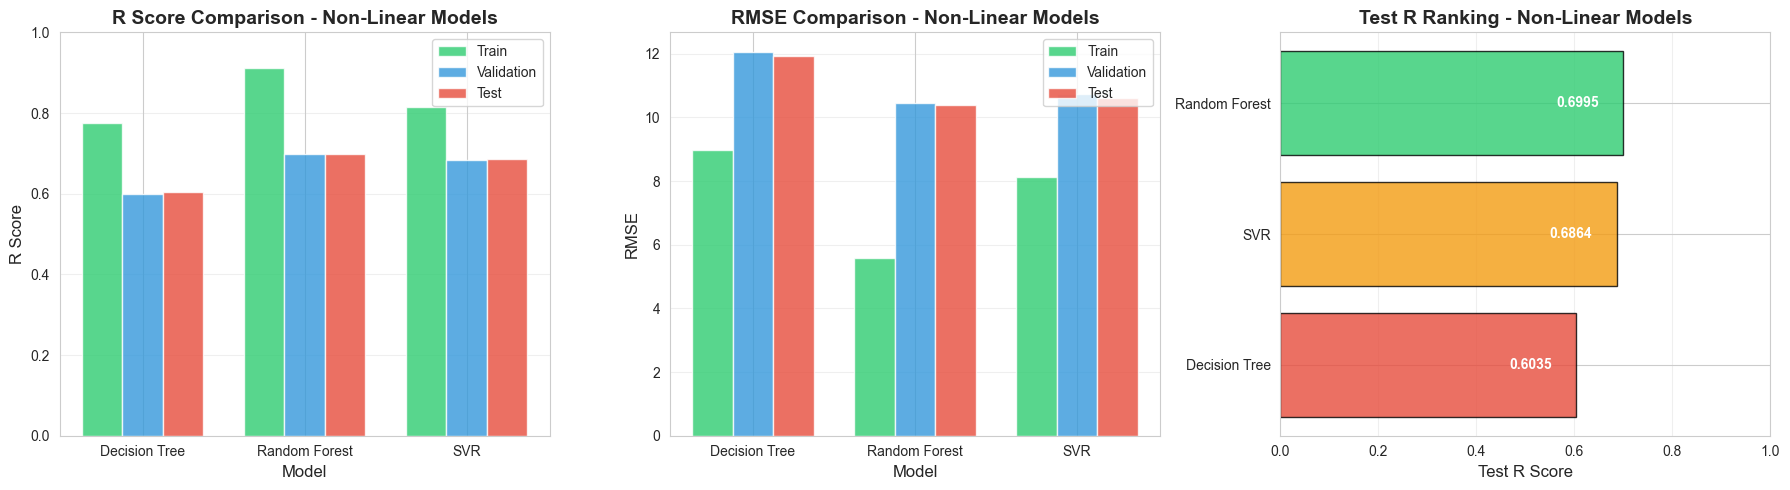

In [35]:
# Visualize non-linear models comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R comparison
ax1 = axes[0]
x = np.arange(len(nonlinear_models_comparison))
width = 0.25
ax1.bar(x - width, nonlinear_models_comparison["Train R"], width, label='Train', alpha=0.8, color='#2ecc71')
ax1.bar(x, nonlinear_models_comparison["Val R"], width, label='Validation', alpha=0.8, color='#3498db')
ax1.bar(x + width, nonlinear_models_comparison["Test R"], width, label='Test', alpha=0.8, color='#e74c3c')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('R Score', fontsize=12)
ax1.set_title('R Score Comparison - Non-Linear Models', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(nonlinear_models_comparison["Model"])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# RMSE comparison
ax2 = axes[1]
ax2.bar(x - width, nonlinear_models_comparison["Train RMSE"], width, label='Train', alpha=0.8, color='#2ecc71')
ax2.bar(x, nonlinear_models_comparison["Val RMSE"], width, label='Validation', alpha=0.8, color='#3498db')
ax2.bar(x + width, nonlinear_models_comparison["Test RMSE"], width, label='Test', alpha=0.8, color='#e74c3c')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('RMSE Comparison - Non-Linear Models', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(nonlinear_models_comparison["Model"])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Test R ranking
ax3 = axes[2]
sorted_models = nonlinear_models_comparison.sort_values("Test R", ascending=True)
colors_rank = ['#e74c3c', '#f39c12', '#2ecc71']
ax3.barh(sorted_models["Model"], sorted_models["Test R"], color=colors_rank, alpha=0.8, edgecolor='black')
ax3.set_xlabel('Test R Score', fontsize=12)
ax3.set_title('Test R Ranking - Non-Linear Models', fontsize=14, fontweight='bold')
ax3.set_xlim([0, 1])
ax3.grid(axis='x', alpha=0.3)

for i, v in enumerate(sorted_models["Test R"]):
    ax3.text(v - 0.05, i, f'{v:.4f}', va='center', ha='right', fontweight='bold', color='white')

plt.tight_layout()
plt.show()


 ---

 # Part 3: Final Model Comparison & Conclusion



 Now we compare all models (both linear and non-linear) to determine the best model for predicting exam scores.



 ---

In [36]:
# Combine all models for final comparison
print("="*60)
print("FINAL COMPARISON:  ALL MODELS")
print("="*60)

all_models_comparison = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "ElasticNet", "Decision Tree", "Random Forest", "SVR"],
    "Train R": [train_r2_ols, train_r2_ridge, train_r2_lasso, train_r2_elastic, train_r2_dt, train_r2_rf, train_r2_svr],
    "Val R": [val_r2_ols, val_r2_ridge, val_r2_lasso, val_r2_elastic, val_r2_dt, val_r2_rf, val_r2_svr],
    "Test R": [test_r2_ols, test_r2_ridge, test_r2_lasso, test_r2_elastic, test_r2_dt, test_r2_rf, test_r2_svr],
    "Test RMSE": [test_rmse_ols, test_rmse_ridge, test_rmse_lasso, test_rmse_elastic, test_rmse_dt, test_rmse_rf, test_rmse_svr],
    "Test MAE":  [test_mae_ols, test_mae_ridge, test_mae_lasso, test_mae_elastic, test_mae_dt, test_mae_rf, test_mae_svr],
    "Model Type": ["Linear", "Linear", "Linear", "Linear", "Non-Linear", "Non-Linear", "Non-Linear"]
})

# Sort by Test R (descending)
all_models_comparison = all_models_comparison.sort_values("Test R", ascending=False).reset_index(drop=True)

print("\n FINAL MODEL RANKINGS (by Test R):\n")
print(all_models_comparison.to_string(index=False))

# Calculate overfitting metric
all_models_comparison["Overfit"] = all_models_comparison["Train R"] - all_models_comparison["Test R"]

print("\n\n OVERFITTING ANALYSIS:\n")
print(all_models_comparison[["Model", "Train R", "Test R", "Overfit"]].to_string(index=False))


FINAL COMPARISON:  ALL MODELS

 FINAL MODEL RANKINGS (by Test R):

        Model  Train R    Val R   Test R  Test RMSE  Test MAE Model Type
        Lasso 0.730179 0.735547 0.737305   9.704331  7.834697     Linear
   ElasticNet 0.730210 0.735436 0.737252   9.705315  7.835568     Linear
        Ridge 0.730343 0.734998 0.737194   9.706381  7.835021     Linear
          OLS 0.730344 0.734975 0.737189   9.706471  7.835014     Linear
Random Forest 0.912722 0.699398 0.699482  10.379461  8.417286 Non-Linear
          SVR 0.813958 0.682592 0.686423  10.602576  8.544720 Non-Linear
Decision Tree 0.774036 0.598814 0.603543  11.921689  9.491101 Non-Linear


 OVERFITTING ANALYSIS:

        Model  Train R   Test R   Overfit
        Lasso 0.730179 0.737305 -0.007126
   ElasticNet 0.730210 0.737252 -0.007041
        Ridge 0.730343 0.737194 -0.006851
          OLS 0.730344 0.737189 -0.006845
Random Forest 0.912722 0.699482  0.213240
          SVR 0.813958 0.686423  0.127535
Decision Tree 0.774036 0.6035

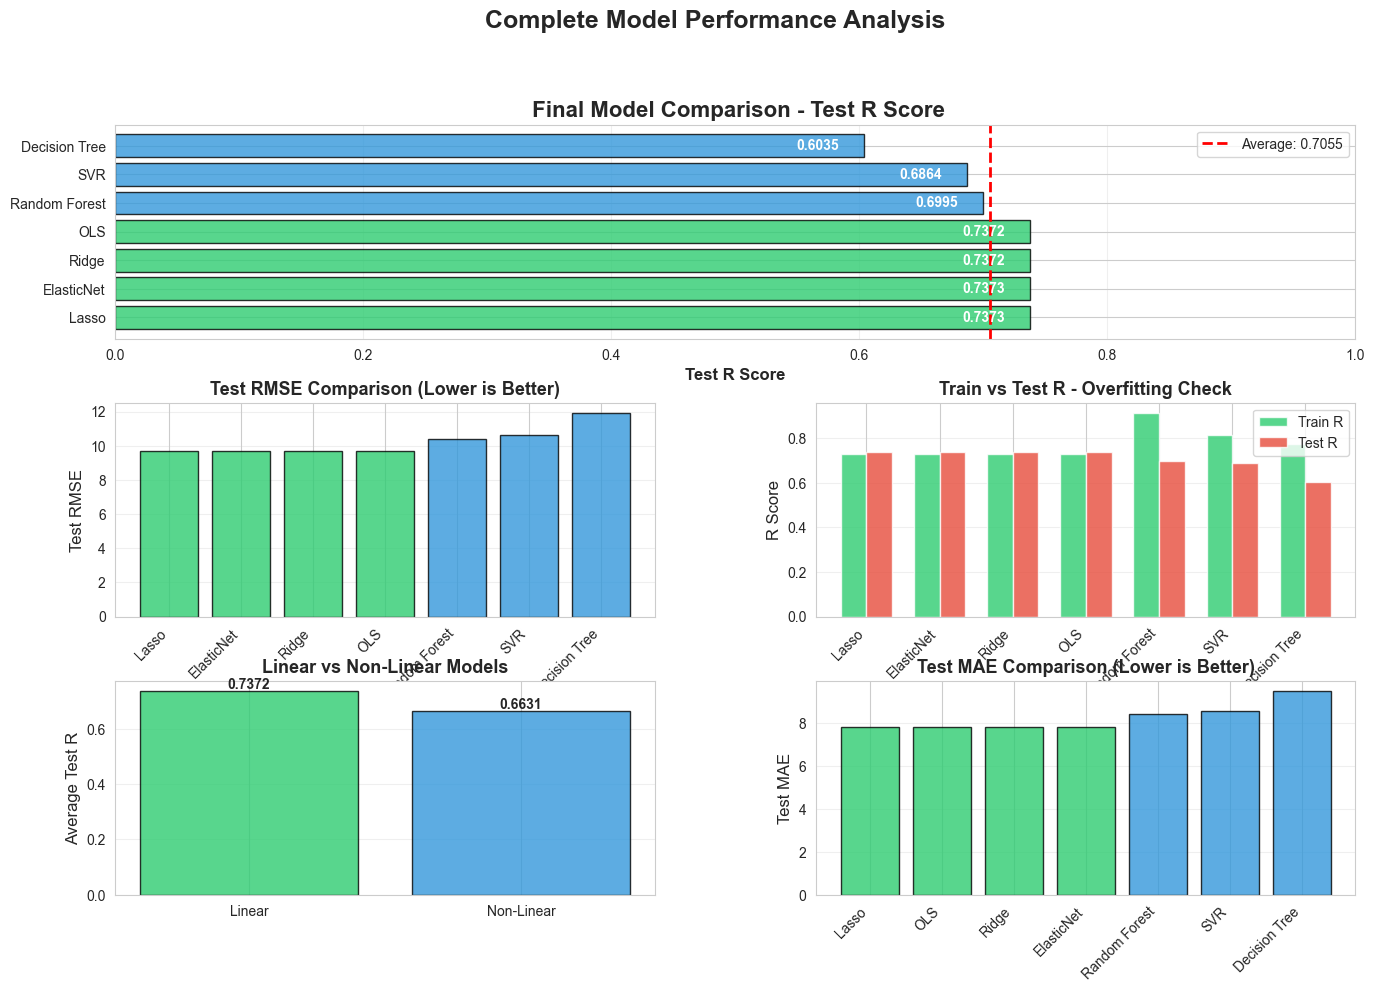

In [37]:
# Comprehensive visualization of all models
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Test R comparison (all models)
ax1 = fig.add_subplot(gs[0, : ])
colors_all = ['#2ecc71' if model_type == 'Linear' else '#3498db' 
              for model_type in all_models_comparison["Model Type"]]
bars = ax1.barh(all_models_comparison["Model"], all_models_comparison["Test R"], 
                color=colors_all, alpha=0.8, edgecolor='black')
ax1.set_xlabel('Test R Score', fontsize=12, fontweight='bold')
ax1.set_title(' Final Model Comparison - Test R Score', fontsize=16, fontweight='bold')
ax1.set_xlim([0, 1])
ax1.grid(axis='x', alpha=0.3)
ax1.axvline(all_models_comparison["Test R"].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Average: {all_models_comparison["Test R"].mean():.4f}')
ax1.legend()

# Add values on bars
for i, (bar, val) in enumerate(zip(bars, all_models_comparison["Test R"])):
    ax1.text(val - 0.02, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
             va='center', ha='right', fontweight='bold', color='white', fontsize=10)

# 2. Test RMSE comparison
ax2 = fig.add_subplot(gs[1, 0])
sorted_rmse = all_models_comparison. sort_values("Test RMSE")
ax2.bar(range(len(sorted_rmse)), sorted_rmse["Test RMSE"], 
        color=colors_all, alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(sorted_rmse)))
ax2.set_xticklabels(sorted_rmse["Model"], rotation=45, ha='right')
ax2.set_ylabel('Test RMSE', fontsize=12)
ax2.set_title('Test RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Train vs Test R (overfitting check)
ax3 = fig.add_subplot(gs[1, 1])
x_pos = np.arange(len(all_models_comparison))
width = 0.35
ax3.bar(x_pos - width/2, all_models_comparison["Train R"], width, 
        label='Train R', alpha=0.8, color='#2ecc71')
ax3.bar(x_pos + width/2, all_models_comparison["Test R"], width, 
        label='Test R', alpha=0.8, color='#e74c3c')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(all_models_comparison["Model"], rotation=45, ha='right')
ax3.set_ylabel('R Score', fontsize=12)
ax3.set_title('Train vs Test R - Overfitting Check', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Model type comparison
ax4 = fig. add_subplot(gs[2, 0])
model_type_avg = all_models_comparison.groupby("Model Type")["Test R"].mean()
colors_type = ['#2ecc71', '#3498db']
ax4.bar(model_type_avg.index, model_type_avg.values, color=colors_type, alpha=0.8, edgecolor='black')
ax4.set_ylabel('Average Test R', fontsize=12)
ax4.set_title('Linear vs Non-Linear Models', fontsize=13, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(model_type_avg.values):
    ax4.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# 5. Test MAE comparison
ax5 = fig.add_subplot(gs[2, 1])
sorted_mae = all_models_comparison.sort_values("Test MAE")
ax5.bar(range(len(sorted_mae)), sorted_mae["Test MAE"], 
        color=colors_all, alpha=0.8, edgecolor='black')
ax5.set_xticks(range(len(sorted_mae)))
ax5.set_xticklabels(sorted_mae["Model"], rotation=45, ha='right')
ax5.set_ylabel('Test MAE', fontsize=12)
ax5.set_title('Test MAE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

plt.suptitle('Complete Model Performance Analysis', fontsize=18, fontweight='bold', y=0.995)
plt.show()


 ---

 #  Final Conclusion & Recommendations



 ## Summary of Results

In [38]:
# Generate final conclusion
print("\n" + "="*70)
print(" FINAL CONCLUSION & RECOMMENDATIONS")
print("="*70)

best_model = all_models_comparison.iloc[0]
print(f"\n{' BEST MODEL:': <30} {best_model['Model']}")
print(f"{'   Test R Score:':<30} {best_model['Test R']:.4f}")
print(f"{'   Test RMSE:':<30} {best_model['Test RMSE']:.4f}")
print(f"{'   Test MAE:':<30} {best_model['Test MAE']:.4f}")
print(f"{'   Model Type:':<30} {best_model['Model Type']}")
print(f"{'   Overfitting (Train-Test):':<30} {best_model['Overfit']:.4f}")

# Interpretation
print("\n" + "-"*70)
print(" INTERPRETATION:")
print("-"*70)

if best_model['Test R'] > 0.85:
    print(f" Excellent model performance (R > 0.85)")
elif best_model['Test R'] > 0.75:
    print(f" Good model performance (R > 0.75)")
elif best_model['Test R'] > 0.65:
    print(f" Moderate model performance (R > 0.65)")
else:
    print(f" Model needs improvement (R < 0.65)")

if best_model['Overfit'] < 0.05:
    print(f" Excellent generalization (minimal overfitting)")
elif best_model['Overfit'] < 0.1:
    print(f" Good generalization (low overfitting)")
else:
    print(f" Moderate overfitting detected")

print(f"\nThe {best_model['Model']} model explains {best_model['Test R']*100:.2f}% of the variance")
print(f"in exam scores, with an average prediction error of {best_model['Test MAE']:.2f} points.")

# Model-specific insights
print("\n" + "-"*70)
print(" KEY INSIGHTS:")
print("-"*70)

print("\n1. LINEAR MODELS:")
linear_models = all_models_comparison[all_models_comparison["Model Type"] == "Linear"]
best_linear = linear_models.iloc[0]
print(f"    Best:  {best_linear['Model']} (R = {best_linear['Test R']:.4f})")
print(f"    Linear models show {linear_models['Test R'].mean():.4f} average R")
print(f"    Good for interpretability and understanding feature relationships")

print("\n2. NON-LINEAR MODELS:")
nonlinear_models = all_models_comparison[all_models_comparison["Model Type"] == "Non-Linear"]
best_nonlinear = nonlinear_models.iloc[0]
print(f"    Best: {best_nonlinear['Model']} (R = {best_nonlinear['Test R']:.4f})")
print(f"    Non-linear models show {nonlinear_models['Test R'].mean():.4f} average R")
print(f"    Better at capturing complex patterns and feature interactions")

# Performance difference
perf_diff = nonlinear_models['Test R']. mean() - linear_models['Test R'].mean()
if perf_diff > 0.05:
    print(f"\n    Non-linear models significantly outperform linear models (+{perf_diff:.4f})")
elif perf_diff > 0.02:
    print(f"\n    Non-linear models show modest improvement over linear models (+{perf_diff:.4f})")
else:
    print(f"\n    Similar performance between linear and non-linear models")

print("\n" + "-"*70)
print(" RECOMMENDATIONS:")
print("-"*70)

if best_model['Model'] == 'Random Forest':
    print("""
1.  USE Random Forest for production predictions
   - Best balance of accuracy, robustness, and generalization
   - Handles non-linear relationships well
   - Provides reliable feature importance

2. Consider ensemble methods or stacking for further improvement

3. For interpretability, use Lasso/Ridge coefficients alongside RF predictions
""")
elif best_model['Model'] in ['Ridge', 'Lasso', 'ElasticNet']: 
    print(f"""
1.  USE {best_model['Model']} for production predictions
   - Excellent interpretability
   - Good performance with regularization
   - Fast predictions
   - Easy to explain to stakeholders

2. Linear relationship is sufficient for this dataset

3. Monitor for non-linear patterns that might benefit from tree-based models
""")
else:
    print(f"""
1.  USE {best_model['Model']} for production predictions
   - Best performance on test set
   - Consider interpretability trade-offs

2. Validate on new data before deployment

3. Monitor for overfitting in production
""")

print("\n" + "-"*70)
print(" FACTORS MOST PREDICTIVE OF EXAM SCORES:")
print("-"*70)

# Get top features from best performing model
if best_model['Model'] == 'Random Forest':
    print("\nBased on Random Forest feature importance:")
    print(feat_imp_df_rf.head(5).to_string(index=False))
elif best_model['Model'] in ['OLS', 'Ridge', 'Lasso', 'ElasticNet']:
    print(f"\nBased on {best_model['Model']} coefficients (absolute values):")
    if best_model['Model'] == 'Ridge':
        print(coef_df_ridge.head(5)[["Feature", "Coefficient"]].to_string(index=False))
    elif best_model['Model'] == 'Lasso':
        print(non_zero_coefs. head(5)[["Feature", "Coefficient"]].to_string(index=False))
    elif best_model['Model'] == 'ElasticNet':
        print(non_zero_coefs_elastic.head(5)[["Feature", "Coefficient"]].to_string(index=False))
    else:
        print(coef_df_ols.head(5)[["Feature", "Coefficient"]].to_string(index=False))

print("\n" + "="*70)
print(" ANALYSIS COMPLETE")
print("="*70 + "\n")



 FINAL CONCLUSION & RECOMMENDATIONS

 BEST MODEL:                   Lasso
   Test R Score:               0.7373
   Test RMSE:                  9.7043
   Test MAE:                   7.8347
   Model Type:                 Linear
   Overfitting (Train-Test):   -0.0071

----------------------------------------------------------------------
 INTERPRETATION:
----------------------------------------------------------------------
 Moderate model performance (R > 0.65)
 Excellent generalization (minimal overfitting)

The Lasso model explains 73.73% of the variance
in exam scores, with an average prediction error of 7.83 points.

----------------------------------------------------------------------
 KEY INSIGHTS:
----------------------------------------------------------------------

1. LINEAR MODELS:
    Best:  Lasso (R = 0.7373)
    Linear models show 0.7372 average R
    Good for interpretability and understanding feature relationships

2. NON-LINEAR MODELS:
    Best: Random Forest (R = 0.69